# MERRA-2 DOD-conditioned precipitation and ERA5 evolution (v4)

This implementation retains the existing JJA Day0 DOD event definition, gridwise JJA P95 treatment and non-P95 climatological/background control, wet-day precipitation criterion, heavy-precipitation definition, and Cartopy map styling. Day0 DOD classifies all three precipitation targets: **Day0**, **Day1**, and the **Day0 + Day1 total**. Calendar-day targets are selected using datetime coordinates, never array position.

In [1]:
import os, re, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
from shapely.geometry import box, Point, Point
from shapely.prepared import prep
from shapely.ops import unary_union
from IPython.display import display

plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white'})
AER_ROOT = Path('/data/ggong/reanalysis/MERRA-2_daily/aerosol')
PR_ROOT = Path('/data/ggong/reanalysis/MERRA-2_daily/precip')
ERA_ROOT = Path('/data/ggong/reanalysis/ERA/daily_MERRA2_grid')
SHAPE_PATH = Path('/data/ggong/shp_file/shp_48states')
YEARS = range(2000, 2015)
JJA_MONTHS = [6, 7, 8]
ANALYSIS_START, ANALYSIS_END = pd.Timestamp('2000-06-01'), pd.Timestamp('2014-08-31')
WET_THRESHOLD, MIN_SAMPLES, N_BINS = 1.0, 10, 15
MAP_EXTENT = [-128, -63, 22, 52]
print('Imports and v4 configuration loaded.')

Imports and v4 configuration loaded.


In [2]:
# Read only the calendar window needed for JJA Day0 events and Day1 targets.
def daily_files(root, prefix=None):
    files = sorted(root.glob('*.nc'))
    if prefix:
        files = [f for f in files if f.name.startswith(prefix)]
    if not files:
        raise FileNotFoundError(root)
    return files

def normalize_time(da, name):
    idx = pd.DatetimeIndex(pd.to_datetime(da.time.values)).normalize()
    if idx.duplicated().any():
        raise ValueError(f'{name}: duplicate dates: {list(idx[idx.duplicated()].unique()[:5])}')
    return da.assign_coords(time=idx).sortby('time')

def standardize_lonlat(da):
    rename = {a:b for a,b in [('latitude','lat'),('longitude','lon')] if a in da.coords or a in da.dims}
    da = da.rename(rename) if rename else da
    if 'lat' not in da.coords or 'lon' not in da.coords: raise ValueError('missing lat/lon')
    if float(da.lon.max()) > 180: da = da.assign_coords(lon=((da.lon + 180) % 360)-180)
    return da.sortby('lat').sortby('lon')

def open_merra_daily(root, variable):
    files = daily_files(root)
    # Filename date check is performed before opening; it reports source-file coverage.
    file_dates = pd.DatetimeIndex([pd.Timestamp(re.search(r'(\d{8})', f.name).group(1)) for f in files])
    expected = pd.date_range(file_dates.min(), file_dates.max(), freq='D')
    print(f'{variable} files: {file_dates.min().date()} to {file_dates.max().date()}, n={len(file_dates)}, duplicates={file_dates.duplicated().sum()}, missing={len(expected.difference(file_dates))}')
    # Retain JJA plus only the three-day May/September buffers for every year;
    # do not accidentally open the continuous 15-year interval between them.
    keep = [f for f,d in zip(files,file_dates) if d.year in YEARS and (d.month in JJA_MONTHS or (d.month == 5 and d.day >= 29) or (d.month == 9 and d.day <= 3))]
    # Files are one day each and filename-sorted, so nested concatenation avoids
    # the expensive coordinate-merging graph created by combine='by_coords'.
    ds = xr.open_mfdataset(keep, combine='nested', concat_dim='time', coords='minimal', data_vars='minimal', compat='override', chunks={'time': 92})
    if variable not in ds.data_vars: raise ValueError(f'{root}: {variable} absent; found {list(ds.data_vars)}')
    return normalize_time(standardize_lonlat(ds[variable]), variable)

def open_era_daily(folder, variable):
    files = [ERA_ROOT/folder/f'ERA5_{folder}_daily_MERRA2grid_{year}_JJA.nc' for year in YEARS]
    missing = [str(f) for f in files if not f.exists()]
    if missing: raise FileNotFoundError(missing[:3])
    ds = xr.open_mfdataset(files, combine='by_coords', chunks=None)
    if variable not in ds.data_vars: raise ValueError(f'{folder}: expected {variable}; found {list(ds.data_vars)}')
    da = normalize_time(standardize_lonlat(ds[variable]), variable)
    keep = (da.time.dt.month.isin(JJA_MONTHS) | ((da.time.dt.month == 5) & (da.time.dt.day >= 29)) | ((da.time.dt.month == 9) & (da.time.dt.day <= 3)))
    return da.where(keep, drop=True)

dod = open_merra_daily(AER_ROOT, 'DUEXTTAU')
dod.attrs['units'] = dod.attrs.get('units') or '1'
precip = open_merra_daily(PR_ROOT, 'PRECTOTCORR')
# The daily MERRA-2 files store PRECTOTCORR as kg m-2 s-1 but omit the units attribute.
# Preserve v3's precipitation convention by converting the flux to mm day-1.
precip = (precip * 86400.0).astype('float32')
precip.attrs.update({'original_units':'kg m-2 s-1 (verified from source product/value scale)',
                     'units':'mm day-1','conversion':'multiplied by 86400'})
era_specs = {'CAPE':('CAPE','CAPE'), 'omega500':('omega500','omega500'), 'omega700':('omega700','omega700'), 'RH700':('RH700','RH700'), 'TCWV':('TCWV','TCWV'), 'Z500':('Z500','Z500')}
era = {name:open_era_daily(folder,var) for name,(folder,var) in era_specs.items()}
# These trimmed arrays are modest (~JJA plus six buffer days on a CONUS grid).
# Loading once prevents every lag/composite from rebuilding and rereading the same file graph.
dod = dod.load(); precip = precip.load(); era = {name:da.load() for name,da in era.items()}
print('Raw datasets opened, units standardized, and JJA-buffer arrays loaded once.')

DUEXTTAU files: 2000-01-01 to 2014-12-31, n=5479, duplicates=0, missing=0


PRECTOTCORR files: 2000-01-01 to 2014-12-31, n=5479, duplicates=0, missing=0


Raw datasets opened, units standardized, and JJA-buffer arrays loaded once.


In [3]:
# Required source metadata and date QC.
all_data = {'MERRA-2 DOD':dod, 'MERRA-2 precipitation':precip, **{f'ERA5 {k}':v for k,v in era.items()}}
expected_retained = pd.DatetimeIndex(np.concatenate([pd.date_range(f'{y}-05-29',f'{y}-09-03',freq='D').values for y in YEARS]))
rows=[]
for name, da in all_data.items():
    idx=pd.DatetimeIndex(da.time.values); expected=expected_retained
    rows.append({'dataset':name,'variable':da.name,'dims':str(da.dims),'units':da.attrs.get('units'),'start':idx.min().date(),'end':idx.max().date(),'retained_days':len(idx),'JJA_days':int(idx.month.isin(JJA_MONTHS).sum()),'duplicate_dates':int(idx.duplicated().sum()),'missing_dates':len(expected.difference(idx)),'lat_n':da.lat.size,'lon_n':da.lon.size})
display(pd.DataFrame(rows))
for da in all_data.values():
    if da.dims != ('time','lat','lon'): raise ValueError(f'unexpected dimensions: {da.dims}')
    if not (np.array_equal(da.lat.values,dod.lat.values) and np.array_equal(da.lon.values,dod.lon.values)): raise ValueError('new datasets are not spatially aligned')
source_common = pd.DatetimeIndex(dod.time.values)
for da in [precip,*era.values()]: source_common=source_common.intersection(pd.DatetimeIndex(da.time.values))
day0_dates = source_common[source_common.month.isin(JJA_MONTHS)]
print('Common JJA Day0:',day0_dates.min().date(),day0_dates.max().date(),'n=',len(day0_dates),'duplicates=',day0_dates.duplicated().sum())
print('Verified ERA5 units:', {k:v.attrs.get('units') for k,v in era.items()})

,dataset,variable,dims,units,start,end,retained_days,JJA_days,duplicate_dates,missing_dates,lat_n,lon_n
0,MERRA-2 DOD,DUEXTTAU,"('time', 'lat', 'lon')",1,2000-05-29,2014-09-03,1470,1380,0,0,71,113
1,MERRA-2 precipitation,PRECTOTCORR,"('time', 'lat', 'lon')",mm day-1,2000-05-29,2014-09-03,1470,1380,0,0,71,113
2,ERA5 CAPE,CAPE,"('time', 'lat', 'lon')",J kg-1,2000-06-01,2014-08-31,1380,1380,0,90,71,113
3,ERA5 omega500,omega500,"('time', 'lat', 'lon')",Pa s-1,2000-06-01,2014-08-31,1380,1380,0,90,71,113
4,ERA5 omega700,omega700,"('time', 'lat', 'lon')",Pa s-1,2000-06-01,2014-08-31,1380,1380,0,90,71,113
5,ERA5 RH700,RH700,"('time', 'lat', 'lon')",%,2000-06-01,2014-08-31,1380,1380,0,90,71,113
6,ERA5 TCWV,TCWV,"('time', 'lat', 'lon')",kg m-2,2000-06-01,2014-08-31,1380,1380,0,90,71,113
7,ERA5 Z500,Z500,"('time', 'lat', 'lon')",m,2000-06-01,2014-08-31,1380,1380,0,90,71,113


Common JJA Day0: 2000-06-01 2014-08-31 n= 1380 duplicates= 0
Verified ERA5 units: {'CAPE': 'J kg-1', 'omega500': 'Pa s-1', 'omega700': 'Pa s-1', 'RH700': '%', 'TCWV': 'kg m-2', 'Z500': 'm'}


In [4]:
# Seven regions from the supplied state shapefiles, using the verified state-abbreviation field.
regions_dict = {
    "NE": ["CT", "DE", "ME", "MD", "MA", "NH", "NJ", "NY", "PA", "RI", "VT", "WV"],
    "Midwest": ["IA", "MI", "MN", "WI", "IL", "IN", "MO", "OH"],
    "SE": ["AL", "FL", "GA", "NC", "SC", "VA", "TN", "KY", "AR", "LA", "MS"],
    "NGP": ["MT", "NE", "ND", "SD", "WY"],
    "SGP": ["KS", "OK", "TX"],
    "SW": ["AZ", "CO", "NM", "UT", "CA", "NV"],
    "NW": ["ID", "OR", "WA"],
}
REGION_ORDER = list(regions_dict)

shps = sorted(SHAPE_PATH.rglob('*.shp'))
parts = [gpd.read_file(f).to_crs('EPSG:4326') for f in shps]
states = gpd.GeoDataFrame(pd.concat(parts, ignore_index=True), geometry='geometry', crs='EPSG:4326')

# Detect rather than assume the abbreviation field.
required_states = {abbr for members in regions_dict.values() for abbr in members}
abbr_candidates = []
for field in states.columns:
    if field == states.geometry.name:
        continue
    values = set(states[field].dropna().astype(str).str.upper())
    if required_states.issubset(values):
        abbr_candidates.append(field)
if not abbr_candidates:
    raise ValueError(f'No state-abbreviation field found; columns={list(states.columns)}')
preferred = [f for f in ['STUSPS', 'STATE_ABBR', 'STATE'] if f in abbr_candidates]
STATE_ABBR_FIELD = preferred[0] if preferred else abbr_candidates[0]
states['state_abbr'] = states[STATE_ABBR_FIELD].astype(str).str.upper()
missing_states = sorted(required_states.difference(states.state_abbr))
if missing_states:
    raise ValueError(f'Missing required states: {missing_states}')
print('Detected shapefile state-abbreviation field:', STATE_ABBR_FIELD)

conus_geom = states.geometry.union_all() if hasattr(states.geometry, 'union_all') else unary_union(states.geometry.values)
lat, lon = dod.lat.values, dod.lon.values

def center_point_mask(geom):
    prepared = prep(geom)
    values = np.array([[prepared.covers(Point(float(x), float(y))) for x in lon] for y in lat], dtype=bool)
    return xr.DataArray(values, coords={'lat': lat, 'lon': lon}, dims=('lat', 'lon'))

land_mask = center_point_mask(conus_geom)
regions = {}
assigned = xr.zeros_like(land_mask, dtype=bool)
for name, abbreviations in regions_dict.items():
    subset = states.loc[states.state_abbr.isin(abbreviations), 'geometry']
    geom = subset.union_all() if hasattr(subset, 'union_all') else unary_union(subset.values)
    # Fixed-order assignment resolves the unlikely case of a grid centre lying exactly on a shared boundary.
    mask = center_point_mask(geom) & land_mask & ~assigned
    regions[name] = {'mask': mask}
    assigned = assigned | mask

region_membership = sum((regions[name]['mask'].astype('int8') for name in REGION_ORDER),
                        start=xr.zeros_like(land_mask, dtype='int8'))
if int(region_membership.max()) > 1:
    raise ValueError('At least one grid cell was assigned to multiple regions')
region_grid_cells = pd.DataFrame([
    {'region': name, 'grid_cells': int(regions[name]['mask'].sum())} for name in REGION_ORDER
])
display(region_grid_cells)
print('Maximum regional memberships per grid cell:', int(region_membership.max()))

Detected shapefile state-abbreviation field: STUSPS


,region,grid_cells
0,NE,206
1,Midwest,477
2,SE,428
3,NGP,431
4,SGP,342
5,SW,586
6,NW,247


Maximum regional memberships per grid cell: 1


In [5]:
# Gridwise JJA DOD P95 treatment and mutually exclusive non-P95 climatological control.
dod_jja = dod.sel(time=day0_dates).load()
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='All-NaN slice encountered', category=RuntimeWarning)
    dod_p95 = (dod_jja.where(land_mask).chunk({'time': -1})
               .quantile(.95, dim='time', skipna=True).compute().squeeze(drop=True))
DOD_PERCENTILE_METHOD = 'gridwise JJA P95 versus non-P95 climatological background'
valid_dod = dod_jja.notnull() & land_mask
events = {
    'P95': valid_dod & (dod_jja >= dod_p95),
    'Climatology': valid_dod & (dod_jja < dod_p95),
}
event_overlap = events['P95'] & events['Climatology']
event_union_mismatch = (events['P95'] | events['Climatology']) != valid_dod
if bool(event_overlap.any()) or bool(event_union_mismatch.any()):
    raise ValueError('Treatment and climatological control are not a mutually exclusive partition')
print('DOD percentile method:', DOD_PERCENTILE_METHOD)
def at_relative_day(da, lag):
    targets = day0_dates + pd.Timedelta(days=int(lag))
    available = pd.DatetimeIndex(da.time.values)
    return da.reindex(time=targets).assign_coords(time=day0_dates)
def grid_day_count(mask):
    return int(mask.where(land_mask, False).sum().compute())
print('P95 Day0 samples (grid-days):', grid_day_count(events['P95']))
print('Non-P95 climatology Day0 samples (grid-days):', grid_day_count(events['Climatology']))
print('Treatment/control overlap:', grid_day_count(event_overlap))


DOD percentile method: gridwise JJA P95 versus non-P95 climatological background
P95 Day0 samples (grid-days): 187474
Non-P95 climatology Day0 samples (grid-days): 3561986
Treatment/control overlap: 0


In [6]:
# Day0 DOD classifies Day0, Day1, and Day0+Day1 precipitation.
# The retained wet-day criterion is precipitation >= WET_THRESHOLD (1.0 mm day-1).
precip_day0 = at_relative_day(precip, 0)
precip_day1 = at_relative_day(precip, 1)
precip_day01 = precip_day0 + precip_day1
precip_by_case = {
    'Day0': precip_day0,
    'Day1': precip_day1,
    'Day0+Day1': precip_day01,
}

heavy_threshold_by_case = {
    case: p.where(land_mask).chunk({'time': -1}).quantile(.95, dim='time', skipna=True).compute().squeeze(drop=True)
    for case, p in precip_by_case.items()
}

def precipitation_metrics(group, precipitation, heavy_threshold):
    eligible = events[group] & precipitation.notnull() & land_mask
    n = eligible.sum('time')
    wet = eligible & (precipitation >= WET_THRESHOLD)
    return xr.Dataset({
        'occurrence': ((precipitation >= WET_THRESHOLD).where(eligible, False).sum('time') / n.where(n > 0)).where(n >= MIN_SAMPLES),
        'wet_intensity': precipitation.where(wet).mean('time', skipna=True).where(wet.sum('time') >= MIN_SAMPLES),
        'heavy_probability': ((precipitation > heavy_threshold).where(eligible, False).sum('time') / n.where(n > 0)).where(n >= MIN_SAMPLES),
        'n_all': n.where(land_mask),
        'n_wet': wet.sum('time').where(land_mask),
    })

pr_stats = {
    case: {group: precipitation_metrics(group, precipitation, heavy_threshold_by_case[case])
           for group in events}
    for case, precipitation in precip_by_case.items()
}

def extract_wet_samples(precipitation, region_mask, condition):
    condition_mask = events[condition]
    use = condition_mask & region_mask & precipitation.notnull() & (precipitation >= WET_THRESHOLD)
    values = precipitation.where(use).values.ravel()
    return values[np.isfinite(values)]

percentiles = np.array([5, 10, 25, 50, 75, 90, 95])
# CONUS is an independent percentile domain; it is intentionally not added to regions_dict.
PERCENTILE_DOMAINS = REGION_ORDER + ['CONUS']

def percentile_domain_mask(domain):
    return land_mask if domain == 'CONUS' else regions[domain]['mask']

precip_samples = {}
sample_rows = []
for case, precipitation in precip_by_case.items():
    precip_samples[case] = {}
    for domain in PERCENTILE_DOMAINS:
        precip_samples[case][domain] = {}
        domain_mask = percentile_domain_mask(domain)
        for condition in ['P95', 'Climatology']:
            sample = extract_wet_samples(precipitation, domain_mask, condition)
            precip_samples[case][domain][condition] = sample
            sample_rows.append({'time_case': case, 'domain': domain, 'condition': condition,
                                'wet_samples': int(sample.size)})
precip_sample_table = pd.DataFrame(sample_rows)
display(precip_sample_table)
# Sum only the seven mutually exclusive regions; CONUS is reported independently.
precip_sample_totals = (precip_sample_table.query("domain != 'CONUS'")
                        .groupby(['time_case', 'condition'], as_index=False)['wet_samples'].sum())
display(precip_sample_totals)
display(precip_sample_table.query("domain == 'CONUS'").reset_index(drop=True))

pair_rows = []
for case, precipitation in precip_by_case.items():
    for group in events:
        valid = events[group] & precipitation.notnull() & land_mask
        pair_rows.append({'time_case': case, 'condition': group,
                          'valid_grid_day_pairs': int(valid.sum()),
                          'Day0 dates with >=1 valid pair': int(valid.any(('lat', 'lon')).sum())})
pair_table = pd.DataFrame(pair_rows)
display(pair_table)

/data/ggong/miniconda3/envs/causal/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


/data/ggong/miniconda3/envs/causal/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


/data/ggong/miniconda3/envs/causal/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


,time_case,domain,condition,wet_samples
0,Day0,NE,P95,7353
1,Day0,NE,Climatology,131509
2,Day0,Midwest,P95,16375
3,Day0,Midwest,Climatology,264590
4,Day0,SE,P95,17017
5,Day0,SE,Climatology,318199
6,Day0,NGP,P95,13223
7,Day0,NGP,Climatology,190432
8,Day0,SGP,P95,9677
9,Day0,SGP,Climatology,156226


,time_case,condition,wet_samples
0,Day0,Climatology,1277397
1,Day0,P95,74089
2,Day0+Day1,Climatology,1842903
3,Day0+Day1,P95,105975
4,Day1,Climatology,1271114
5,Day1,P95,76760


,time_case,domain,condition,wet_samples
0,Day0,CONUS,P95,74089
1,Day0,CONUS,Climatology,1277397
2,Day1,CONUS,P95,76760
3,Day1,CONUS,Climatology,1271114
4,Day0+Day1,CONUS,P95,105975
5,Day0+Day1,CONUS,Climatology,1842903


,time_case,condition,valid_grid_day_pairs,Day0 dates with >=1 valid pair
0,Day0,P95,187474,971
1,Day0,Climatology,3561986,1380
2,Day1,P95,187474,971
3,Day1,Climatology,3561986,1380
4,Day0+Day1,P95,187474,971
5,Day0+Day1,Climatology,3561986,1380


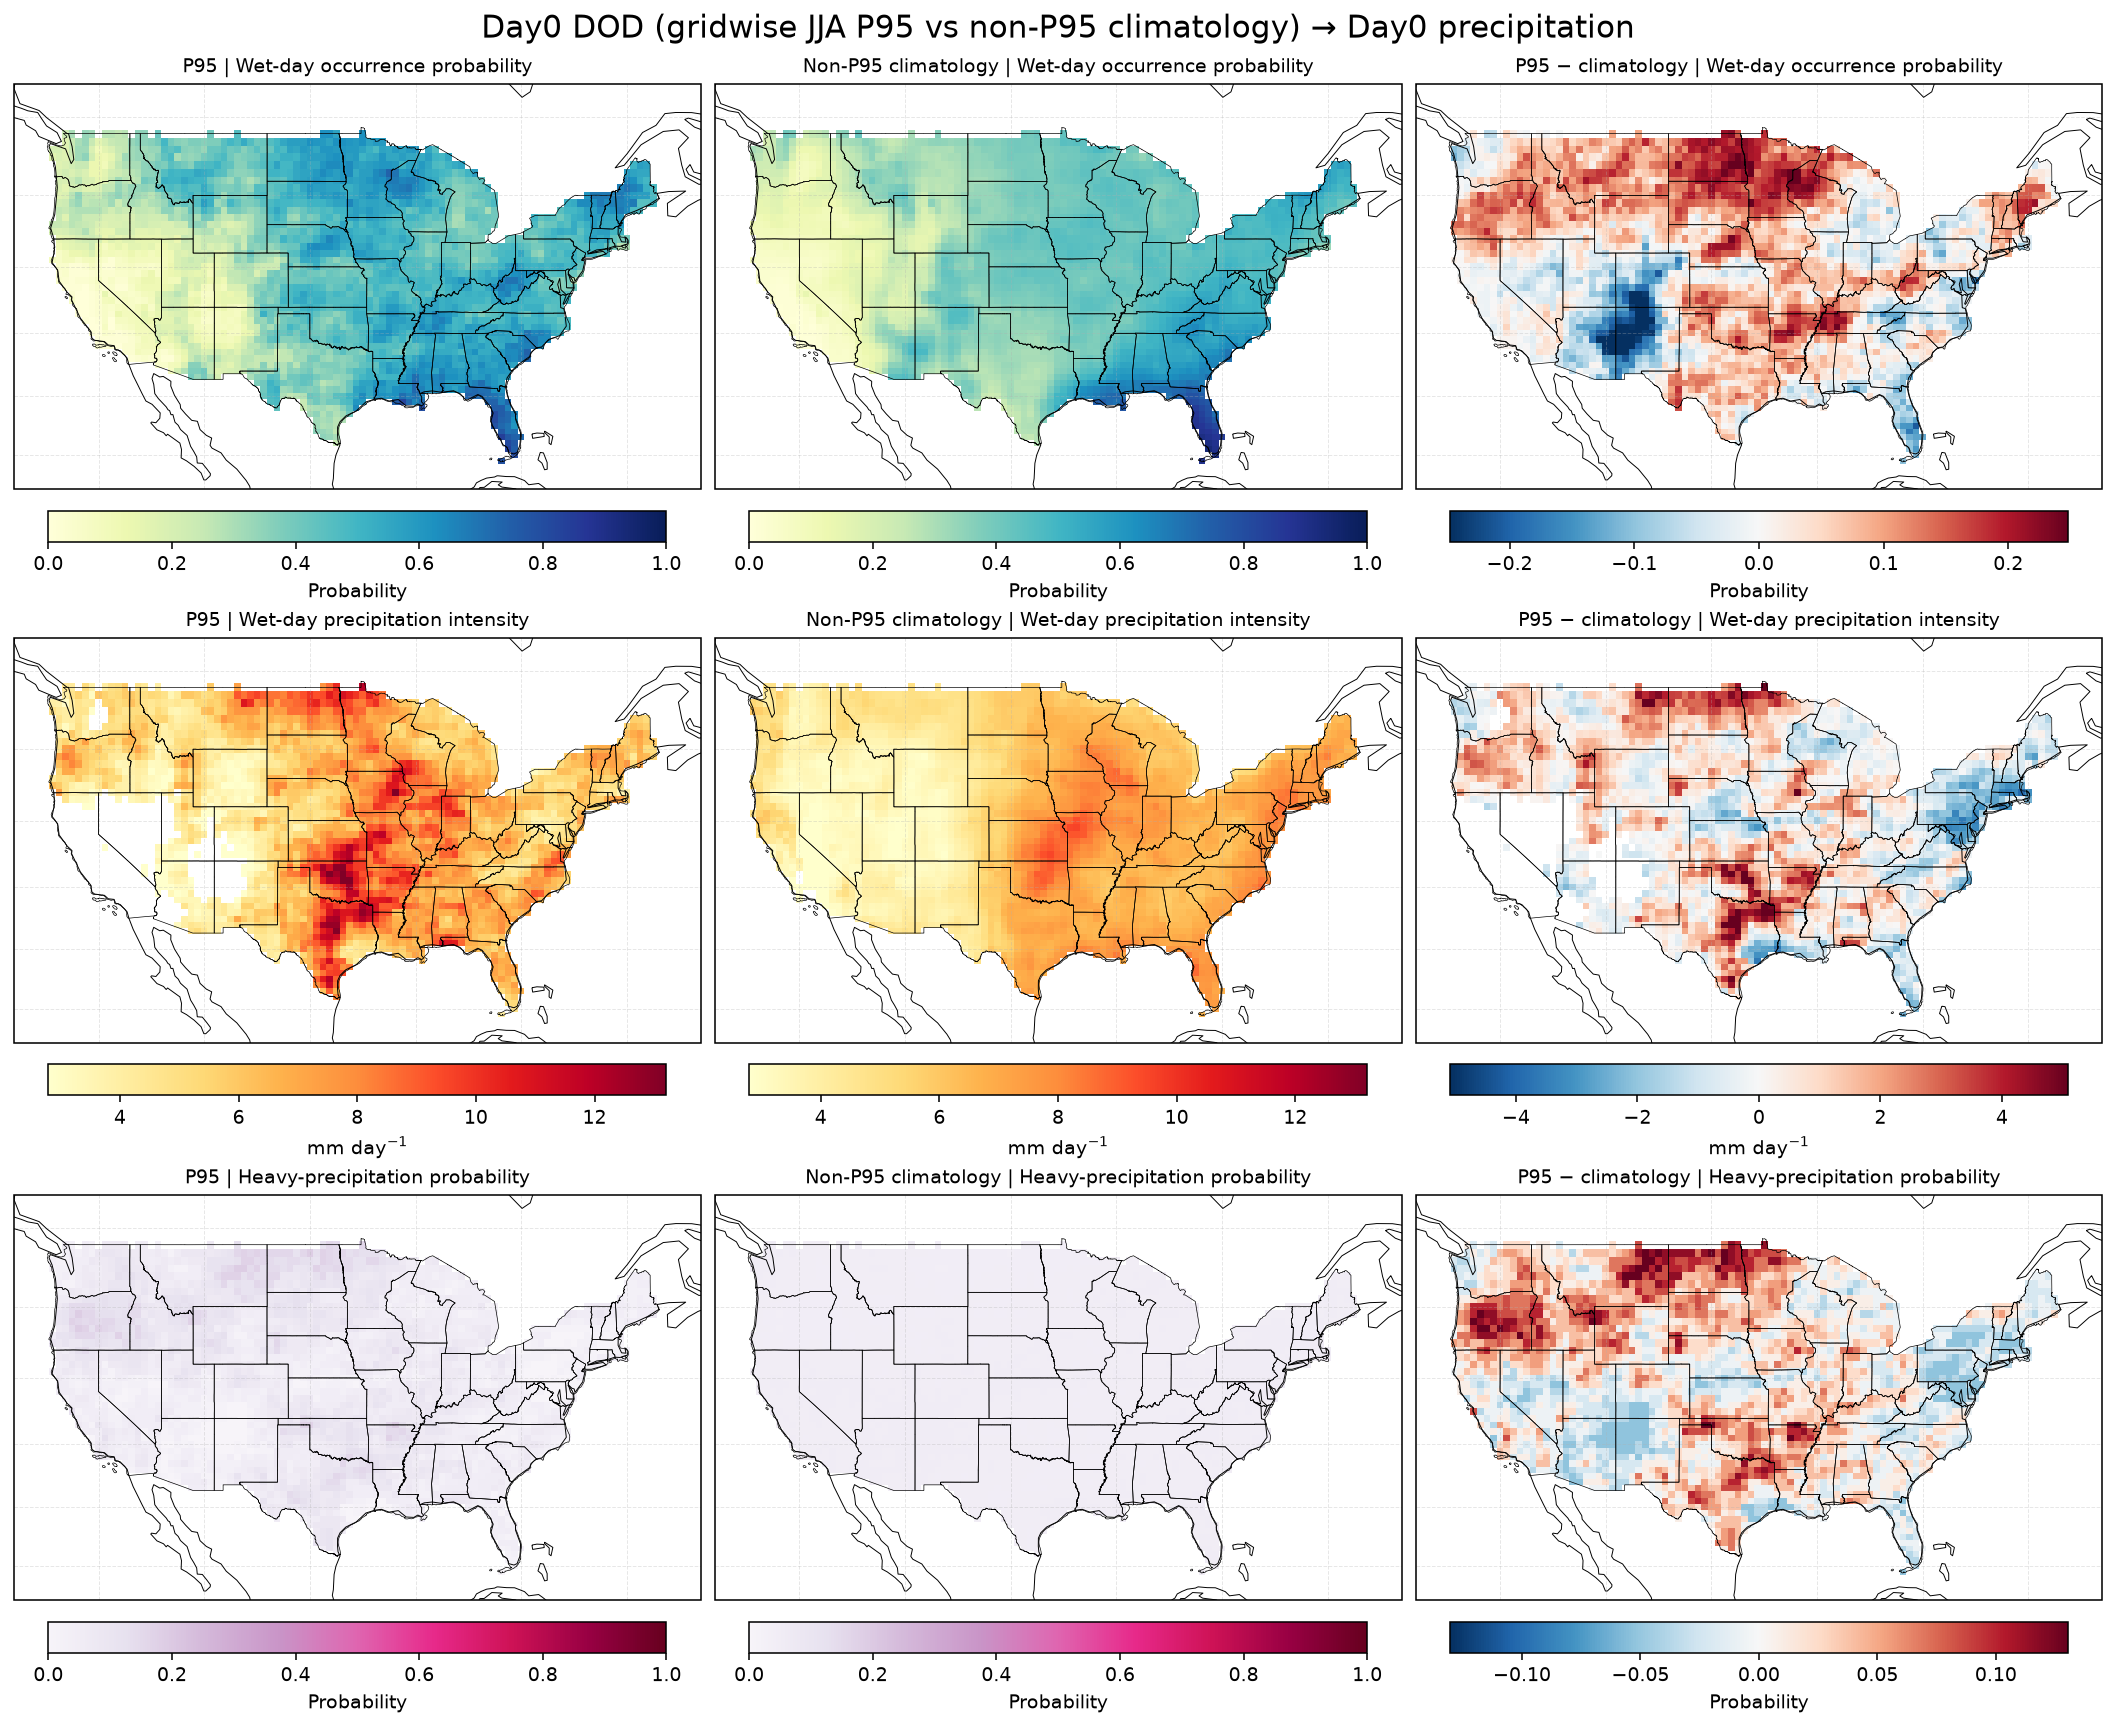

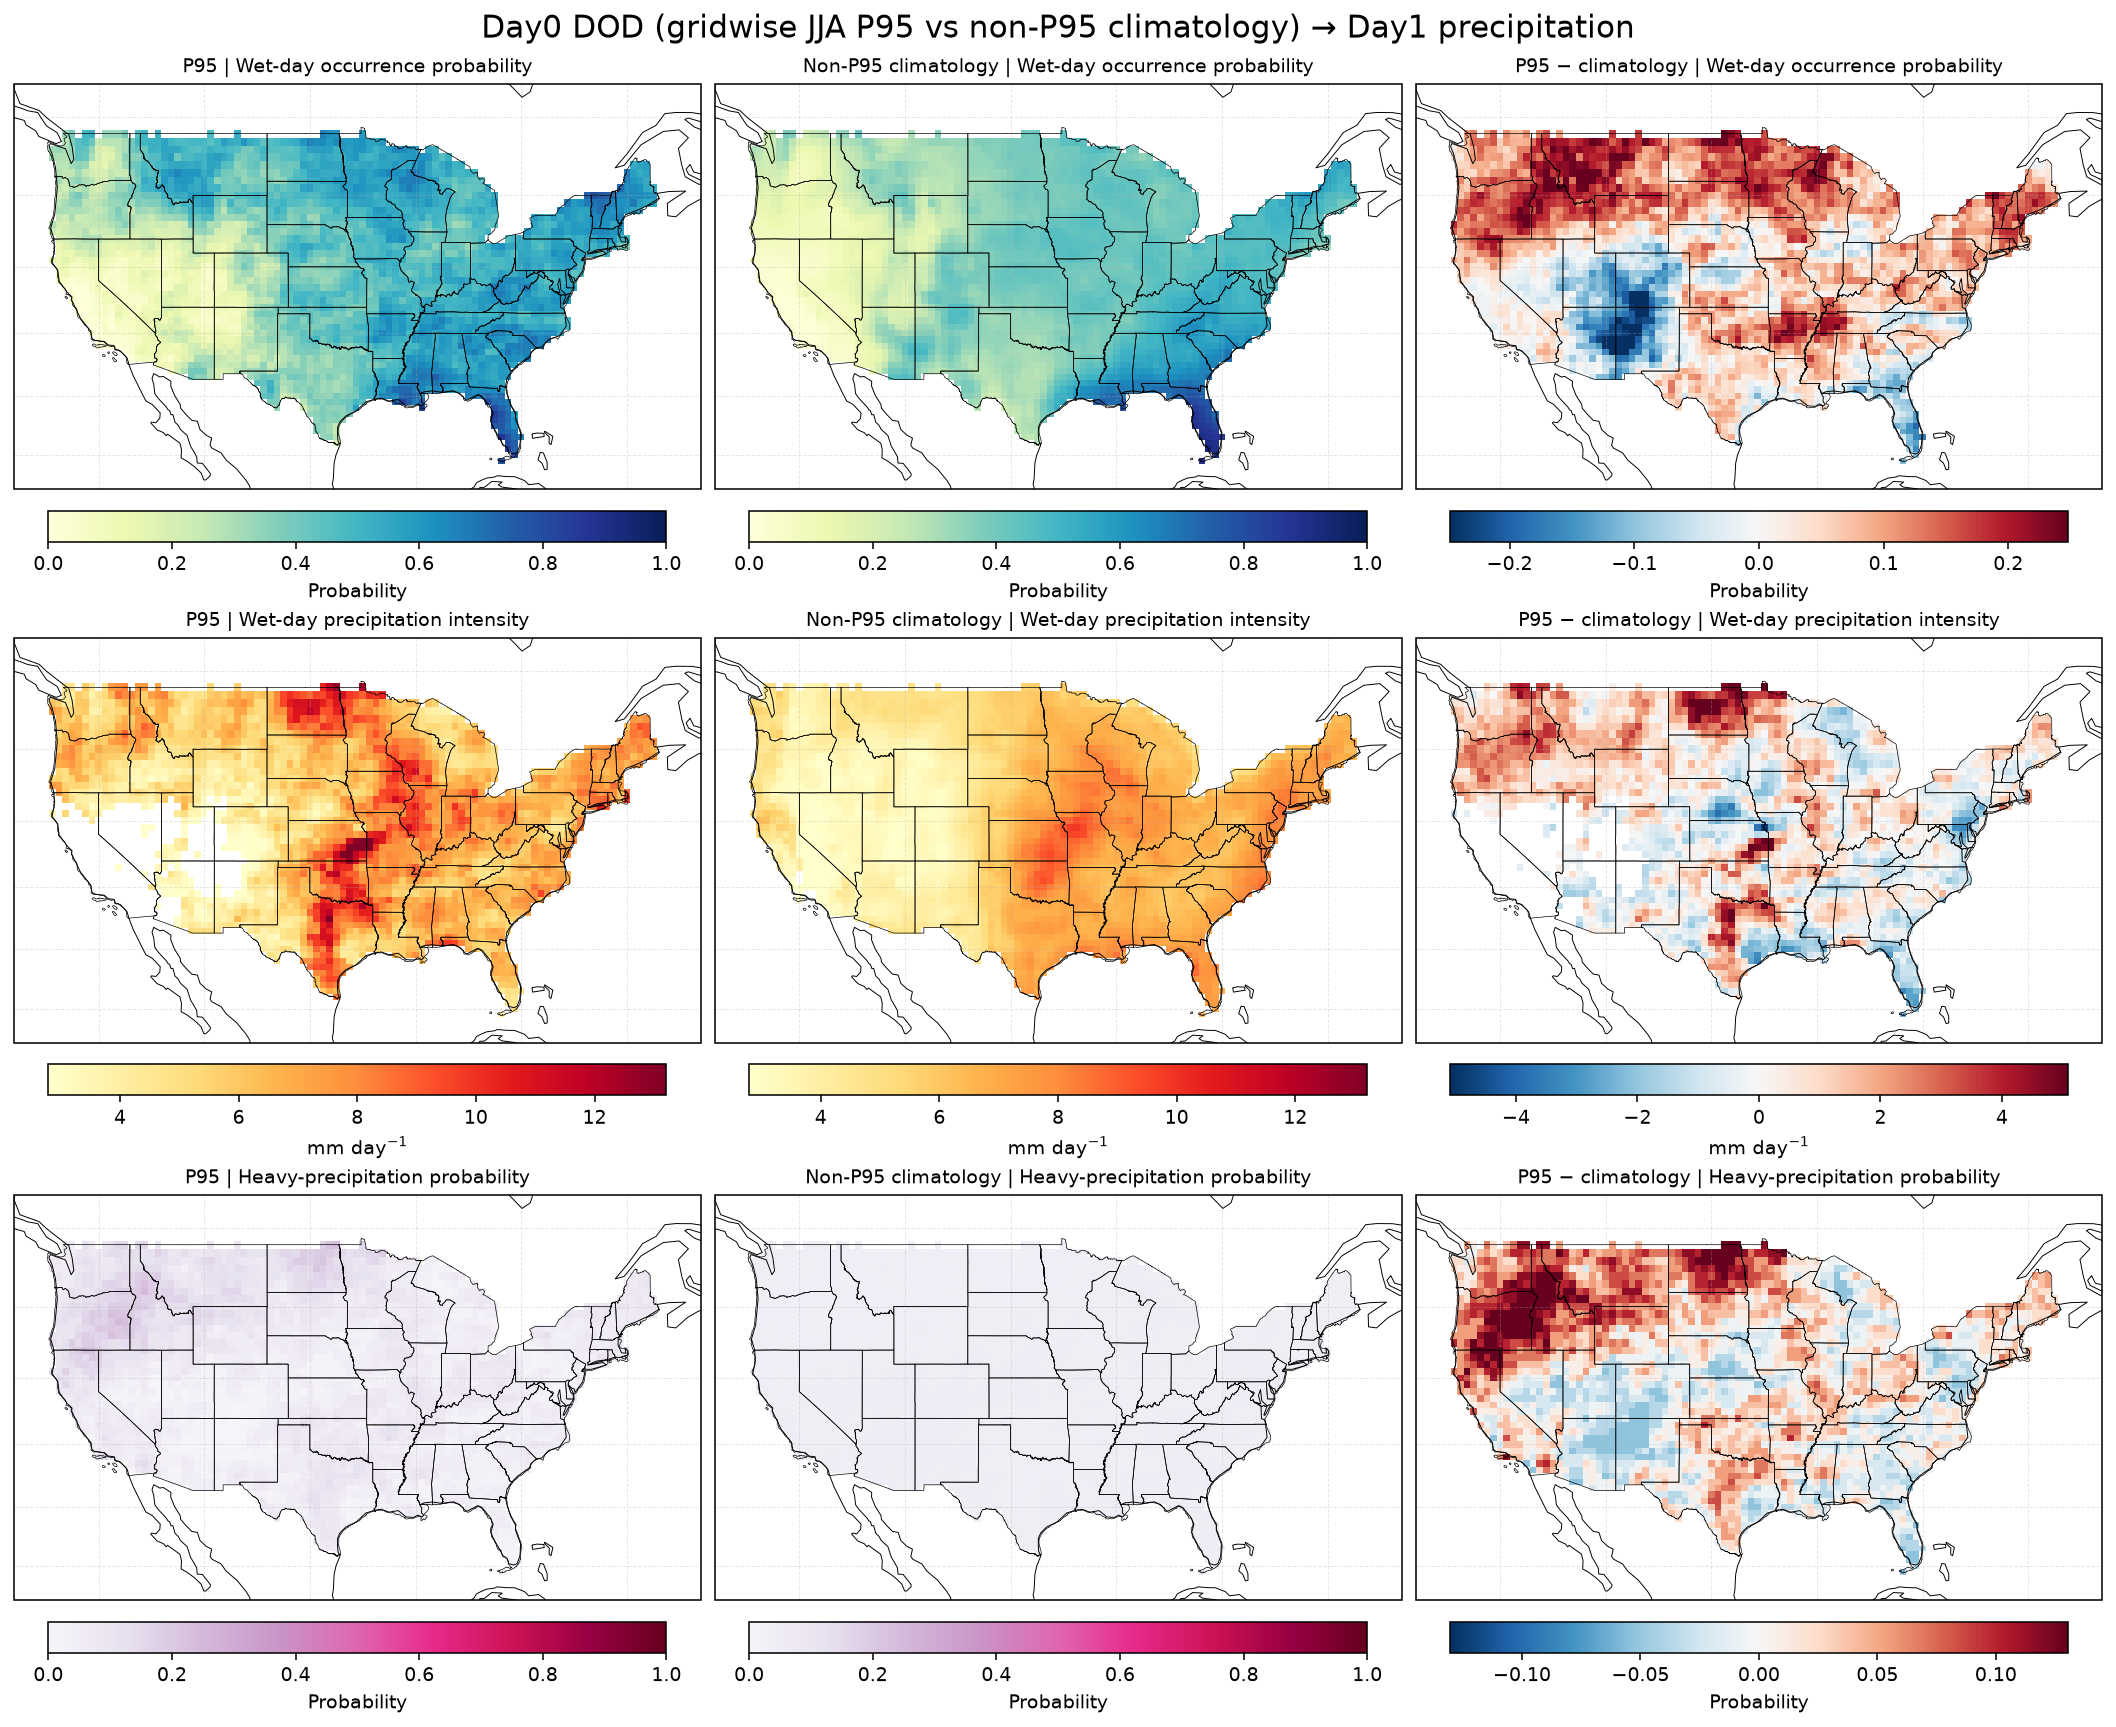

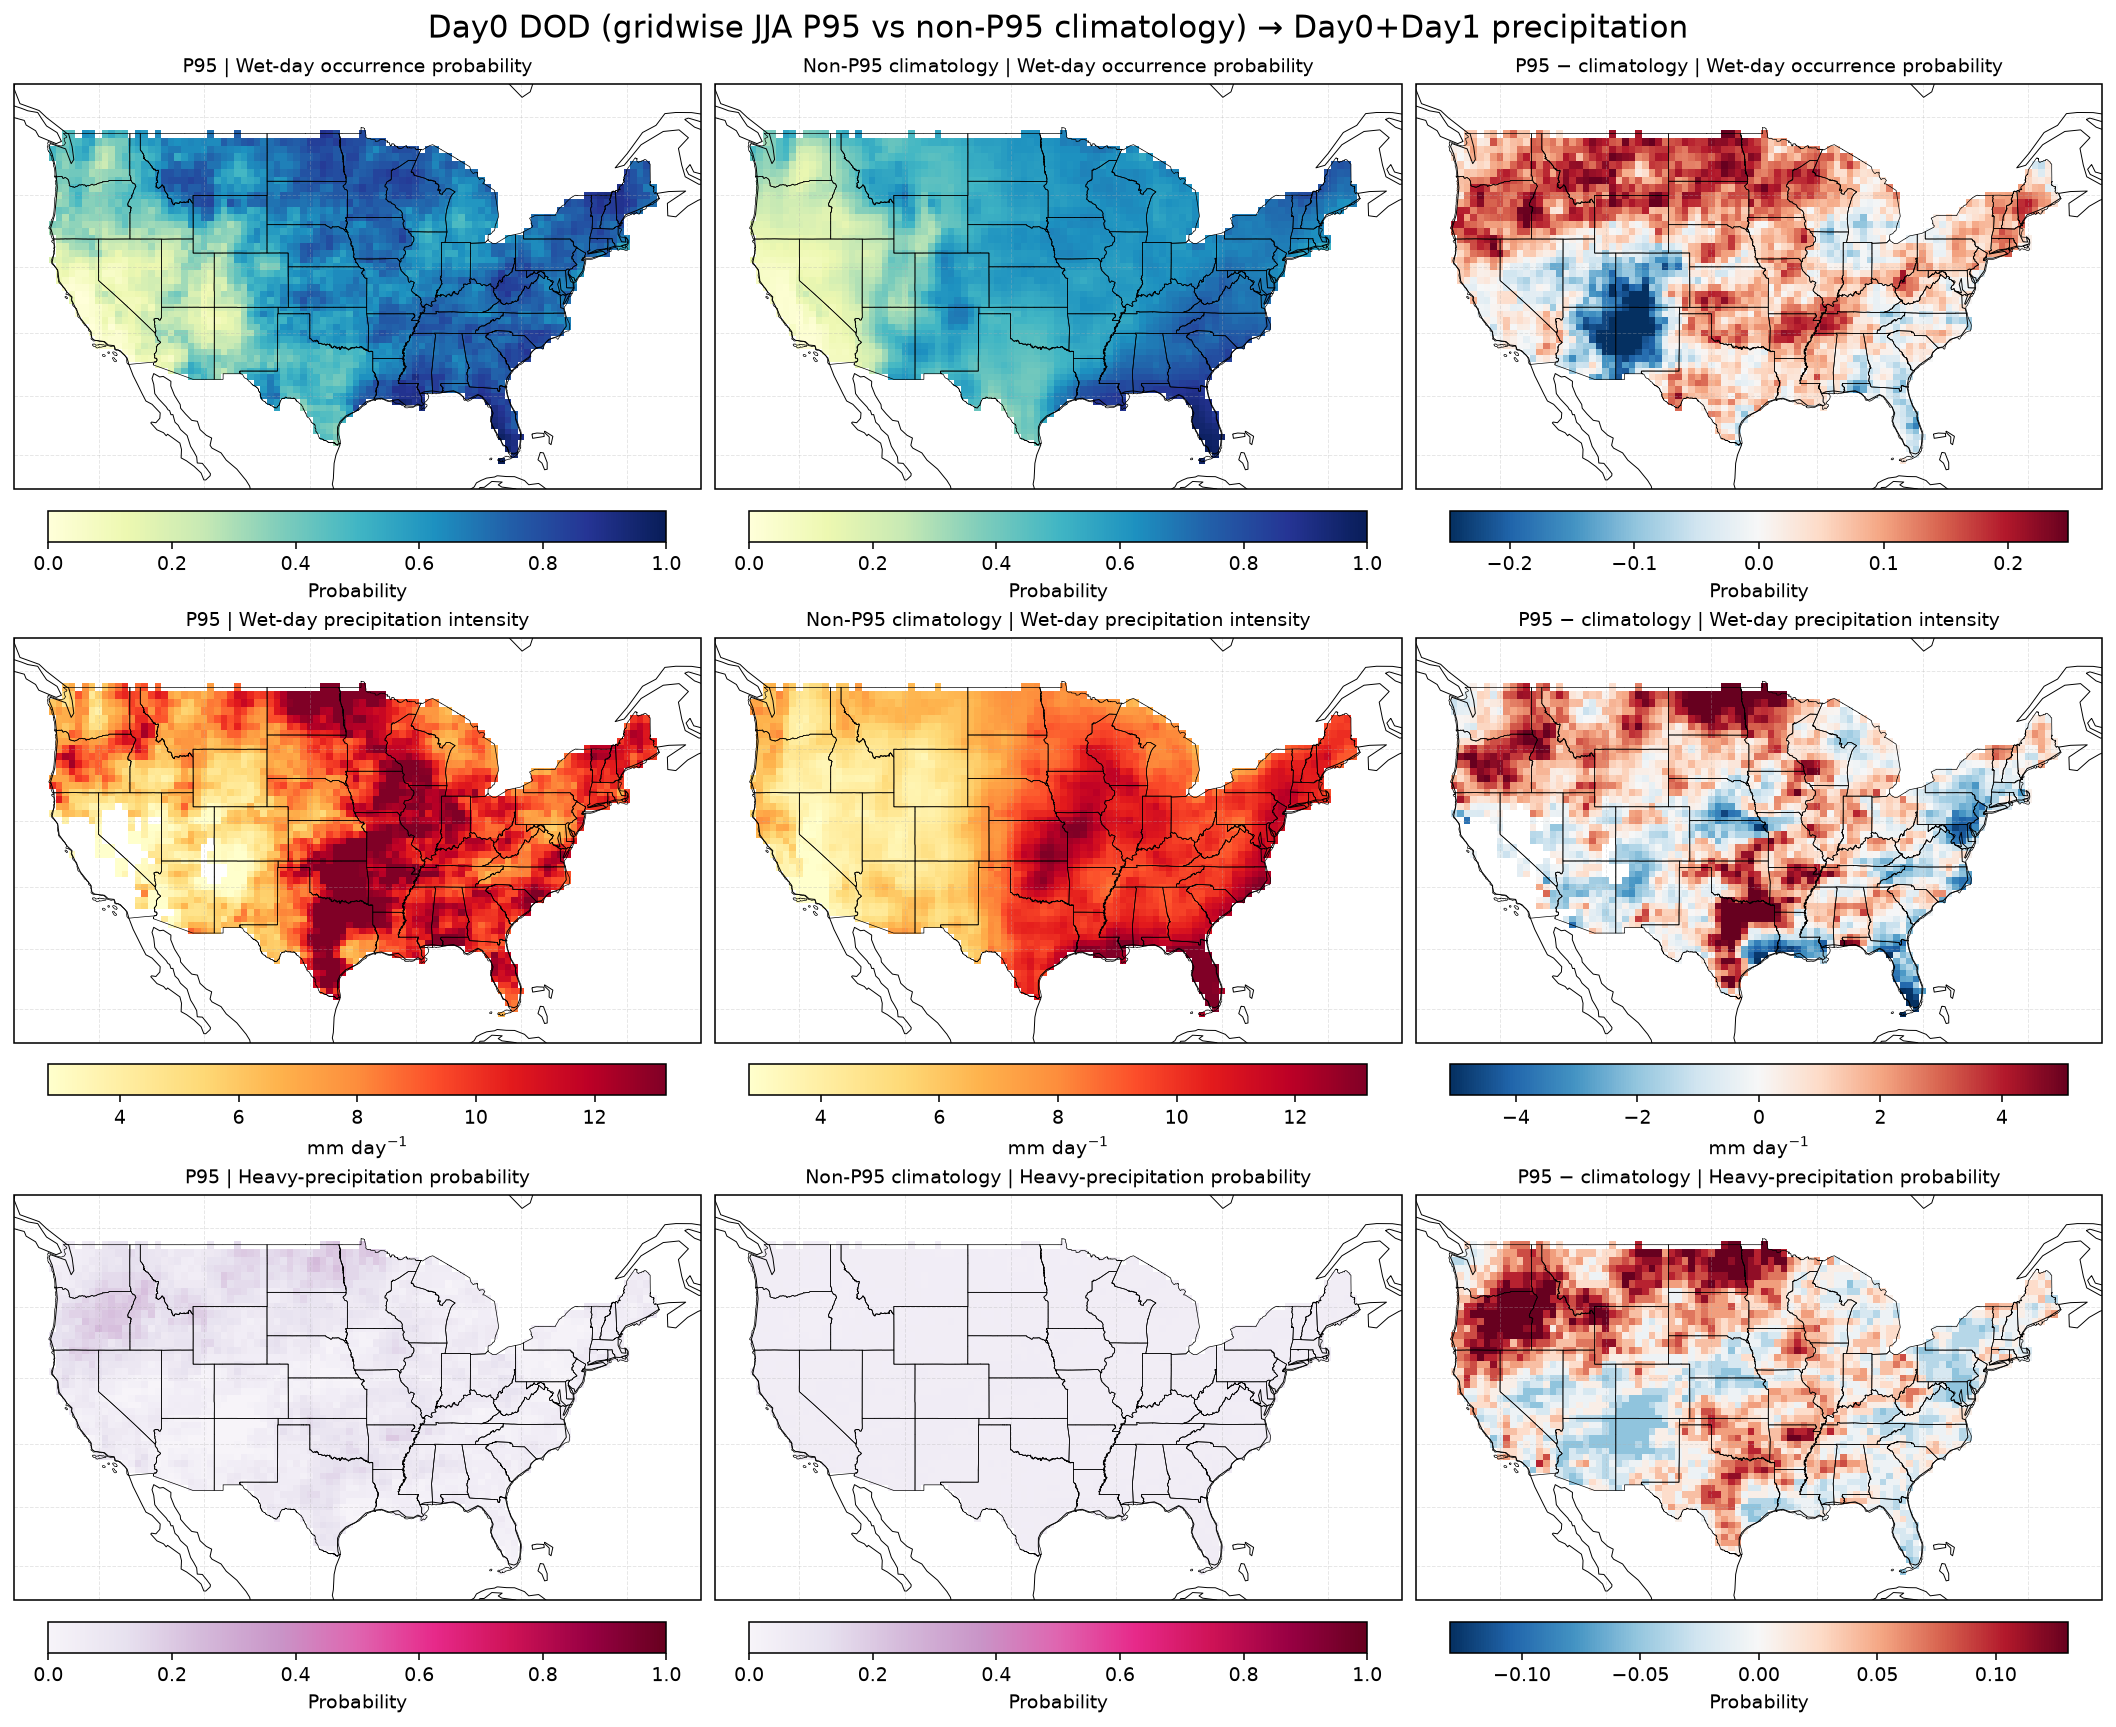

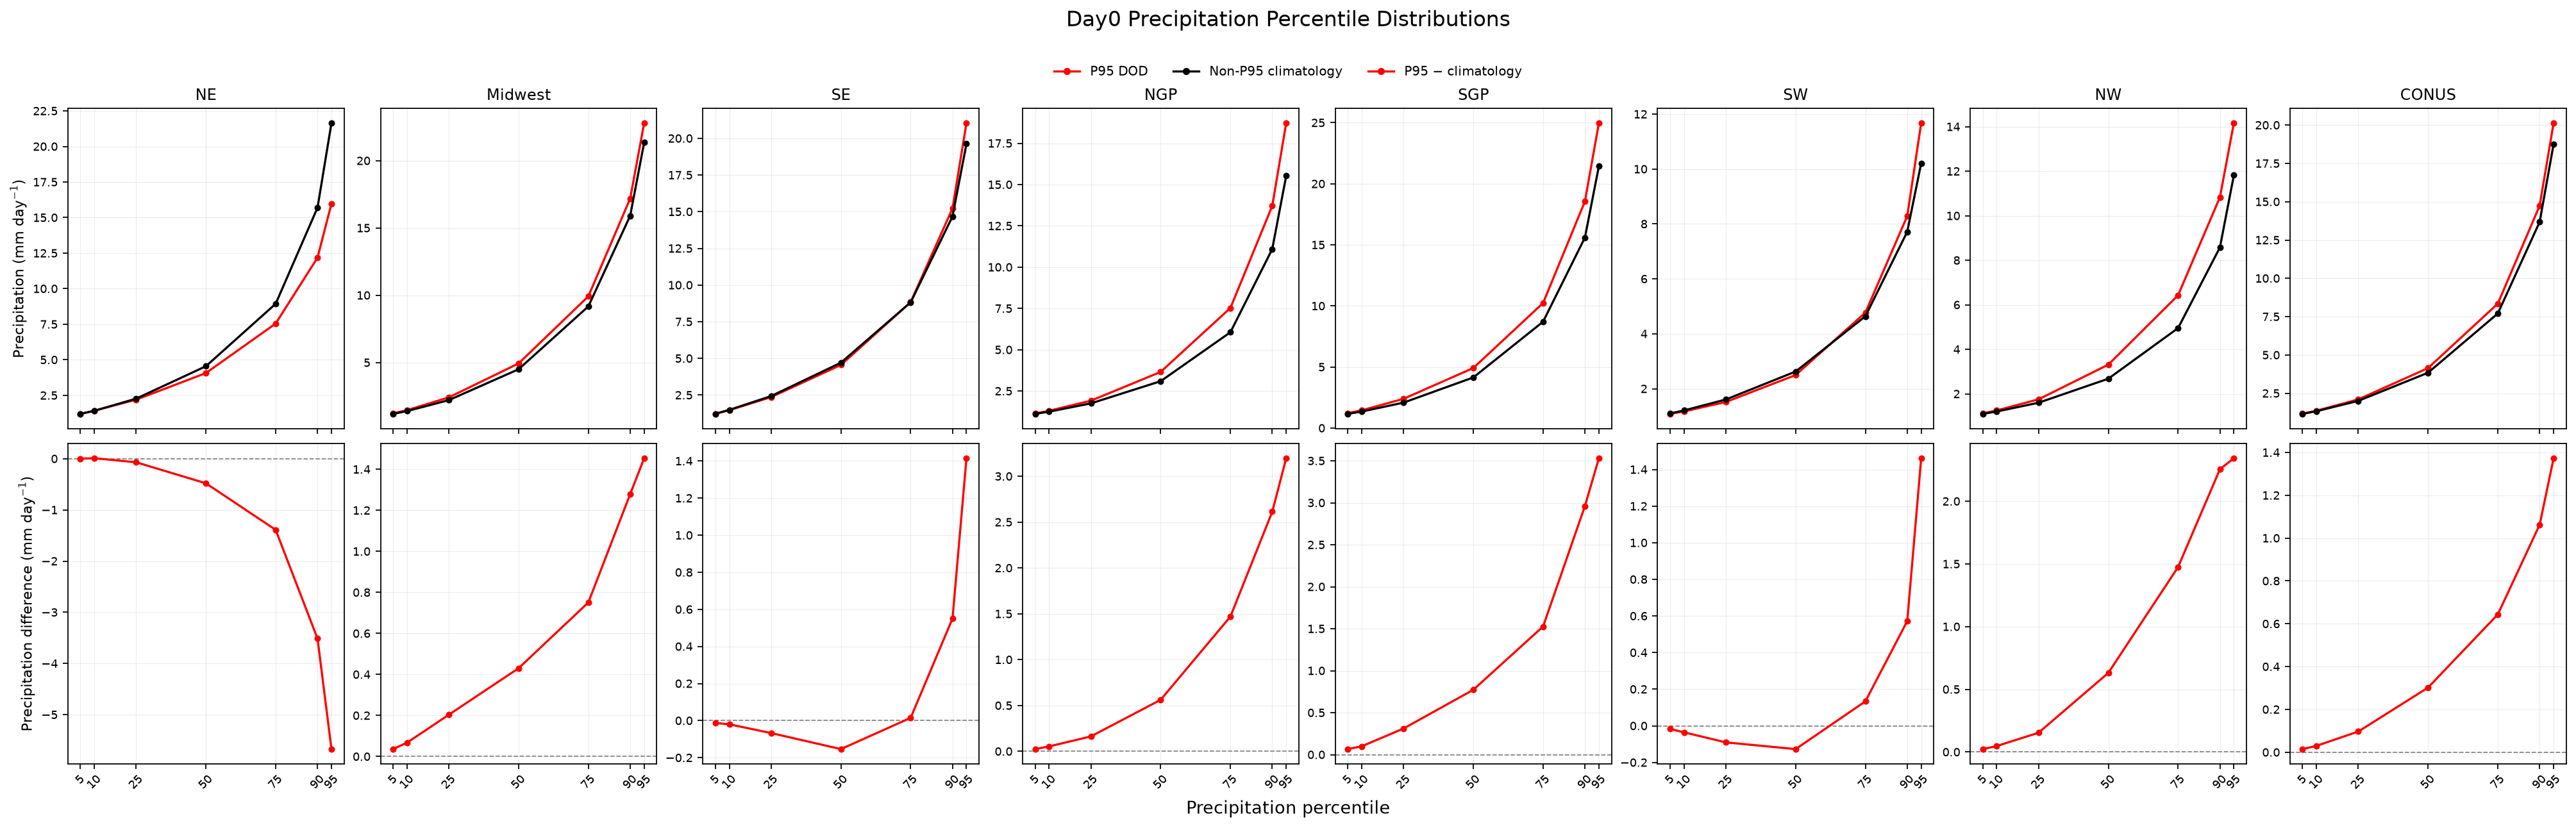

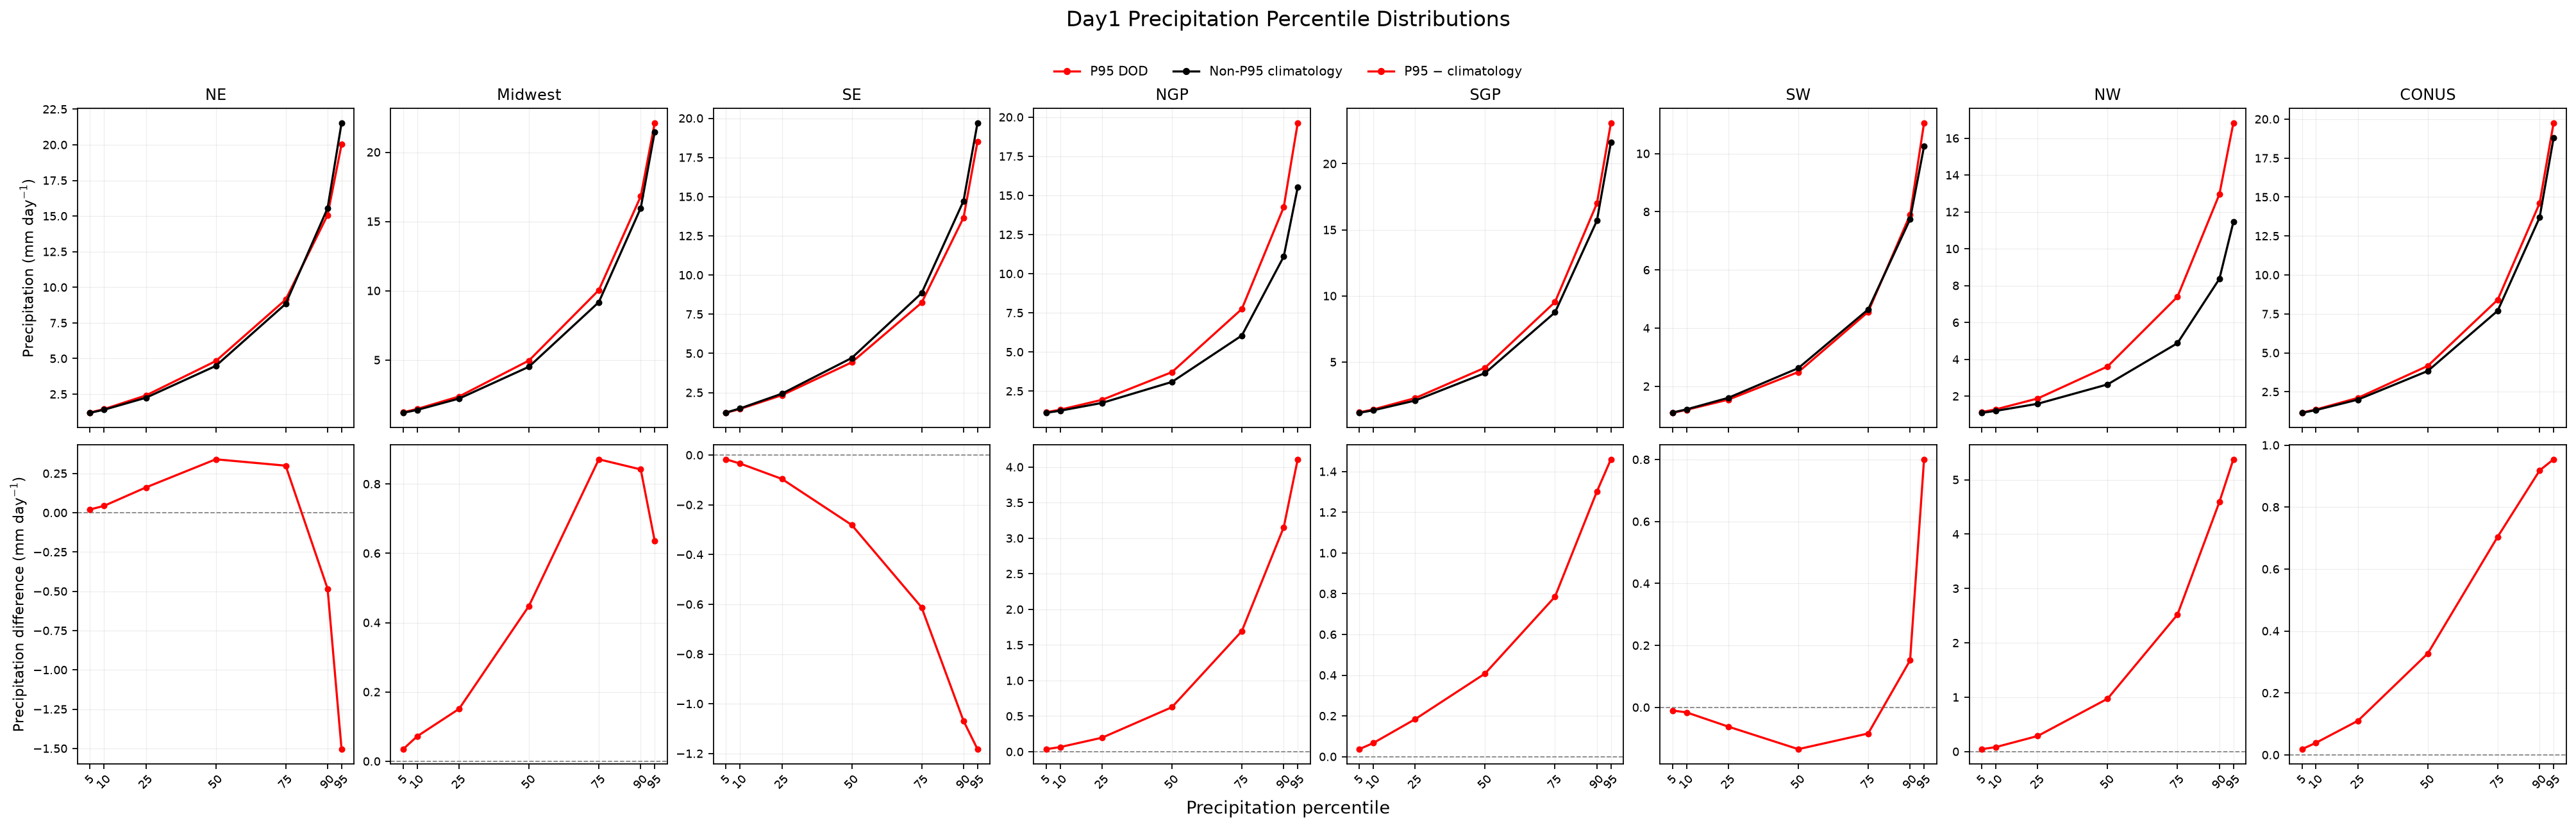

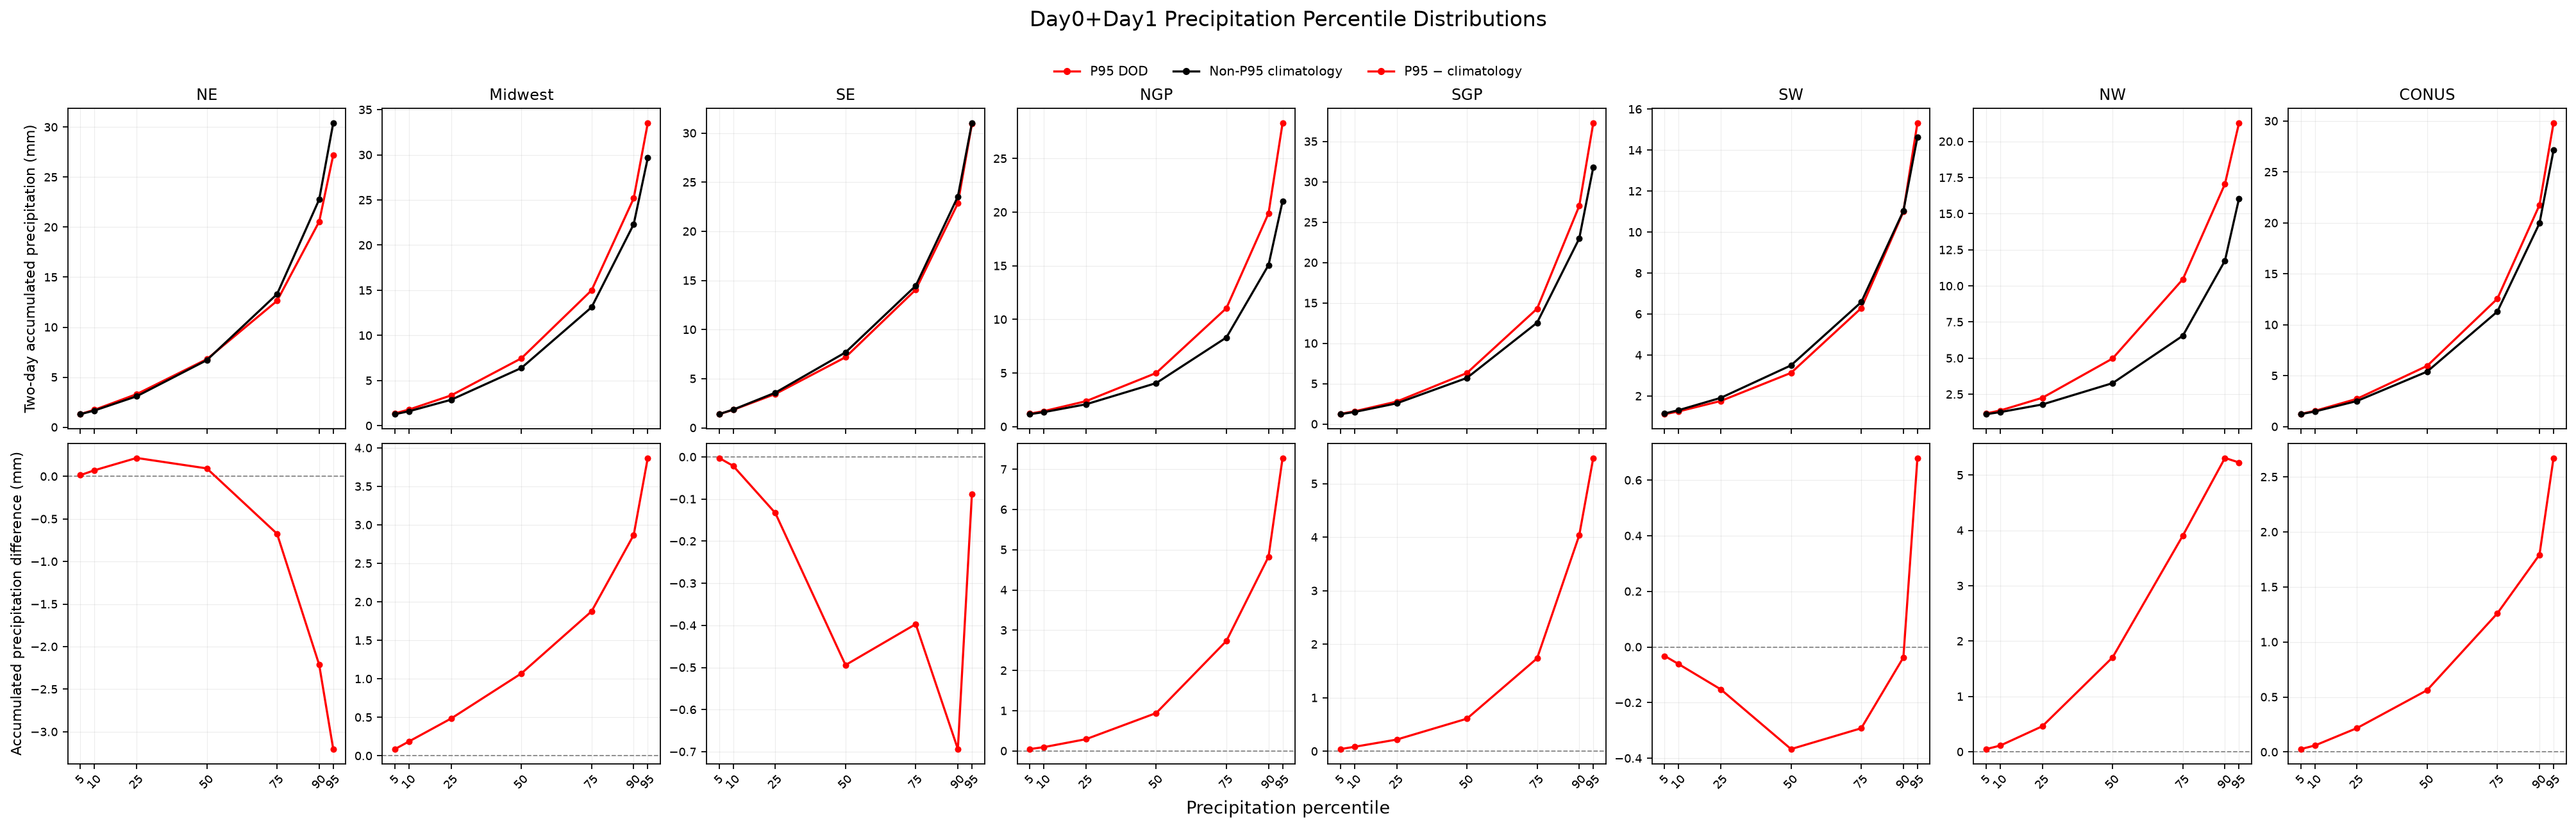

In [7]:
# Spatial precipitation maps for Day0, Day1, and the Day0+Day1 total.
def setup_map_ax(ax):
    ax.set_extent(MAP_EXTENT, crs=ccrs.PlateCarree())
    ax.coastlines(resolution='110m', linewidth=.5, zorder=5)
    ax.add_geometries(states.geometry, crs=ccrs.PlateCarree(), facecolor='none',
                      edgecolor='black', linewidth=.35, zorder=6)
    ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False, linestyle='--', alpha=.3, linewidth=.5)

def symmax(arrays):
    finite = [np.asarray(a)[np.isfinite(a)] for a in arrays]
    vals = np.concatenate([v for v in finite if v.size]) if any(v.size for v in finite) else np.array([])
    return max(float(np.nanpercentile(np.abs(vals), 98)), 1e-6) if vals.size else 1.

metric_specs = [
    ('occurrence', 'Wet-day occurrence probability', 'Probability', 'YlGnBu'),
    ('wet_intensity', 'Wet-day precipitation intensity', 'mm day$^{-1}$', 'YlOrRd'),
    ('heavy_probability', 'Heavy-precipitation probability', 'Probability', 'PuRd'),
]

def precipitation_map_limits(metric):
    raw = [pr_stats[case][group][metric].values for case in precip_by_case for group in events]
    finite = np.concatenate([a[np.isfinite(a)] for a in raw])
    lo = 0.0 if metric in ['occurrence', 'heavy_probability'] else float(np.nanpercentile(finite, 2))
    hi = 1.0 if metric in ['occurrence', 'heavy_probability'] else float(np.nanpercentile(finite, 98))
    diffs = [(pr_stats[case]['P95'][metric] - pr_stats[case]['Climatology'][metric]).values
             for case in precip_by_case]
    return lo, hi, symmax(diffs)

precipitation_spatial_limits = {metric: precipitation_map_limits(metric) for metric, _, _, _ in metric_specs}

def plot_precipitation_maps(case):
    fig, axs = plt.subplots(3, 3, figsize=(15, 12.2), dpi=140,
                            subplot_kw={'projection': ccrs.Mercator()}, constrained_layout=True)
    for row, (metric, label, units, cmap) in enumerate(metric_specs):
        p95 = pr_stats[case]['P95'][metric]
        background = pr_stats[case]['Climatology'][metric]
        lo, hi, dv = precipitation_spatial_limits[metric]
        panels = [(p95, 'P95', cmap, lo, hi),
                  (background, 'Non-P95 climatology', cmap, lo, hi),
                  (p95-background, 'P95 − climatology', 'RdBu_r', -dv, dv)]
        for col, (da, condition, cm, vmin, vmax) in enumerate(panels):
            ax = axs[row, col]
            im = ax.pcolormesh(lon, lat, da, transform=ccrs.PlateCarree(), cmap=cm,
                               vmin=vmin, vmax=vmax, shading='auto')
            setup_map_ax(ax)
            ax.set_title(f'{condition} | {label}', fontsize=10)
            fig.colorbar(im, ax=ax, orientation='horizontal', pad=.04, label=units, shrink=.9)
    fig.suptitle(f'Day0 DOD (gridwise JJA P95 vs non-P95 climatology) → {case} precipitation', fontsize=16)
    plt.show(); plt.close(fig)

for case in precip_by_case:
    plot_precipitation_maps(case)

def calculate_percentile_curves(case, domain):
    curves = {condition: np.nanpercentile(precip_samples[case][domain][condition], percentiles)
              for condition in ['P95', 'Climatology']}
    curves['P95-Climatology'] = curves['P95'] - curves['Climatology']
    return curves

precip_percentile_curves = {
    case: {domain: calculate_percentile_curves(case, domain) for domain in PERCENTILE_DOMAINS}
    for case in precip_by_case
}

def plot_precip_percentile_curves(case):
    fig, axes = plt.subplots(2, 8, figsize=(25, 7.2), dpi=160, sharex=True, constrained_layout=True)
    absolute_specs = [('P95', 'red', 'P95 DOD'), ('Climatology', 'black', 'Non-P95 climatology')]
    difference_specs = [('P95-Climatology', 'red', 'P95 − climatology')]
    for col, domain in enumerate(PERCENTILE_DOMAINS):
        ax_abs, ax_diff = axes[0, col], axes[1, col]
        curves = precip_percentile_curves[case][domain]
        for key, color, label in absolute_specs:
            ax_abs.plot(percentiles, curves[key], color=color, marker='o', markersize=3.5,
                        linewidth=1.5, label=label)
        for key, color, label in difference_specs:
            ax_diff.plot(percentiles, curves[key], color=color, marker='o', markersize=3.5,
                         linewidth=1.5, label=label)
        ax_diff.axhline(0, color='gray', linestyle='--', linewidth=.8, zorder=0)
        ax_abs.set_title(domain, fontsize=11)
        for ax in (ax_abs, ax_diff):
            ax.set_xticks(percentiles); ax.grid(alpha=.22, linewidth=.55)
            ax.tick_params(axis='x', labelrotation=45, labelsize=8); ax.tick_params(axis='y', labelsize=8)
    if case == 'Day0+Day1':
        axes[0, 0].set_ylabel('Two-day accumulated precipitation (mm)')
        axes[1, 0].set_ylabel('Accumulated precipitation difference (mm)')
    else:
        axes[0, 0].set_ylabel('Precipitation (mm day$^{-1}$)')
        axes[1, 0].set_ylabel('Precipitation difference (mm day$^{-1}$)')
    fig.supxlabel('Precipitation percentile')
    legend_handles = [plt.Line2D([0], [0], color=color, marker='o', markersize=4,
                                  linewidth=1.5, label=label)
                      for _, color, label in absolute_specs + difference_specs]
    fig.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(.5, 1.04),
               ncol=3, frameon=False, fontsize=9)
    fig.suptitle(f'{case} Precipitation Percentile Distributions', fontsize=15, y=1.10)
    plt.show(); plt.close(fig)

for case in precip_by_case:
    plot_precip_percentile_curves(case)


In [8]:
# Physical-value TCWV × omega700 binning for Day0, Day1, and Day0+Day1 precipitation.
# Day0+Day1 uses Day0 meteorology while precipitation is the two-day total.
REGIONAL_BIN_COUNT = 15
CONUS_BIN_COUNT = 20
BINNING_CASES = ['Day0', 'Day1', 'Day0+Day1']
BINNING_CONDITIONS = ['P95', 'Climatology']
BINNING_DOMAINS = ['CONUS'] + REGION_ORDER
METEOROLOGY_DAY = {'Day0': 0, 'Day1': 1, 'Day0+Day1': 0}

def physical_range(da):
    values = da.sel(time=day0_dates).where(land_mask).values
    return tuple(float(v) for v in np.nanpercentile(values, [1, 99]))

tcwv_range = physical_range(era['TCWV'])
omega_range = physical_range(era['omega700'])
regional_xedges = np.linspace(*tcwv_range, REGIONAL_BIN_COUNT+1)
regional_yedges = np.linspace(*omega_range, REGIONAL_BIN_COUNT+1)
conus_xedges = np.linspace(*tcwv_range, CONUS_BIN_COUNT+1)
conus_yedges = np.linspace(*omega_range, CONUS_BIN_COUNT+1)

print('Regional shared 15x15 TCWV physical-value bin edges:', regional_xedges)
print('Regional shared 15x15 omega700 physical-value bin edges:', regional_yedges)
print('CONUS 20x20 TCWV physical-value bin edges:', conus_xedges)
print('CONUS 20x20 omega700 physical-value bin edges:', conus_yedges)
print('CONUS TCWV plotting range:', tcwv_range, era['TCWV'].attrs.get('units'))
print('CONUS omega700 plotting range:', omega_range, era['omega700'].attrs.get('units'))

def domain_edges(domain):
    return (conus_xedges, conus_yedges) if domain == 'CONUS' else (regional_xedges, regional_yedges)

def binned_stat(condition, region_mask, case, xedges, yedges):
    precipitation = precip_by_case[case]
    met_day = METEOROLOGY_DAY[case]
    x = at_relative_day(era['TCWV'], met_day)
    y = at_relative_day(era['omega700'], met_day)
    condition_mask = events[condition]
    use = condition_mask & region_mask & precipitation.notnull() & x.notnull() & y.notnull()
    X, Y, P = [z.where(use).values.ravel() for z in [x, y, precipitation]]
    ok = np.isfinite(X) & np.isfinite(Y) & np.isfinite(P)
    X, Y, P = X[ok], Y[ok], P[ok]
    n, _, _ = np.histogram2d(Y, X, bins=[yedges, xedges])
    wet = P >= WET_THRESHOLD
    nw, _, _ = np.histogram2d(Y[wet], X[wet], bins=[yedges, xedges])
    total, _, _ = np.histogram2d(Y[wet], X[wet], bins=[yedges, xedges], weights=P[wet])
    occurrence = np.full_like(n, np.nan, dtype=float)
    intensity = np.full_like(nw, np.nan, dtype=float)
    np.divide(nw, n, out=occurrence, where=n >= MIN_SAMPLES)
    np.divide(total, nw, out=intensity, where=nw >= MIN_SAMPLES)
    return {'occurrence': occurrence, 'intensity': intensity, 'count': n, 'wet_count': nw,
            'samples': int(P.size), 'wet_samples': int(wet.sum()),
            'meteorology_day': met_day, 'precipitation_case': case}

binning = {}
binning_sample_rows = []
for domain in BINNING_DOMAINS:
    mask = land_mask if domain == 'CONUS' else regions[domain]['mask']
    xedges, yedges = domain_edges(domain)
    binning[domain] = {}
    for case in BINNING_CASES:
        binning[domain][case] = {}
        for condition in BINNING_CONDITIONS:
            result = binned_stat(condition, mask, case, xedges, yedges)
            binning[domain][case][condition] = result
            binning_sample_rows.append({'domain': domain, 'time_case': case, 'condition': condition,
                                        'samples': result['samples'], 'wet_samples': result['wet_samples'],
                                        'occupied_bins': int((result['count'] > 0).sum()),
                                        'bin_shape': f'{len(yedges)-1} x {len(xedges)-1}',
                                        'meteorology_day': result['meteorology_day'],
                                        'precipitation_case': result['precipitation_case']})
binning_sample_table = pd.DataFrame(binning_sample_rows)
display(binning_sample_table)
print('2-D binning time cases completed:', BINNING_CASES)
print('2-D domains completed:', BINNING_DOMAINS)

Regional shared 15x15 TCWV physical-value bin edges: [ 5.65811228  8.83235516 12.00659804 15.18084092 18.3550838  21.52932668
 24.70356956 27.87781244 31.05205532 34.2262982  37.40054108 40.57478396
 43.74902684 46.92326973 50.09751261 53.27175549]
Regional shared 15x15 omega700 physical-value bin edges: [-0.53868859 -0.47319466 -0.40770072 -0.34220678 -0.27671285 -0.21121891
 -0.14572497 -0.08023104 -0.0147371   0.05075683  0.11625077  0.18174471
  0.24723864  0.31273258  0.37822651  0.44372045]
CONUS 20x20 TCWV physical-value bin edges: [ 5.65811228  8.03879444 10.4194766  12.80015876 15.18084092 17.56152308
 19.94220524 22.3228874  24.70356956 27.08425172 29.46493388 31.84561604
 34.2262982  36.60698036 38.98766252 41.36834468 43.74902684 46.12970901
 48.51039117 50.89107333 53.27175549]
CONUS 20x20 omega700 physical-value bin edges: [-0.53868859 -0.48956814 -0.44044769 -0.39132724 -0.34220678 -0.29308633
 -0.24396588 -0.19484543 -0.14572497 -0.09660452 -0.04748407  0.00163638
  0.0

,domain,time_case,condition,samples,wet_samples,occupied_bins,bin_shape,meteorology_day,precipitation_case
0,CONUS,Day0,P95,187474,74089,396,20 x 20,0,Day0
1,CONUS,Day0,Climatology,3561986,1277397,400,20 x 20,0,Day0
2,CONUS,Day1,P95,187269,76696,393,20 x 20,1,Day1
3,CONUS,Day1,Climatology,3521436,1258932,400,20 x 20,1,Day1
4,CONUS,Day0+Day1,P95,187474,105975,396,20 x 20,0,Day0+Day1
5,CONUS,Day0+Day1,Climatology,3561986,1842903,400,20 x 20,0,Day0+Day1
6,NE,Day0,P95,14214,7353,180,15 x 15,0,Day0
7,NE,Day0,Climatology,270066,131509,211,15 x 15,0,Day0
8,NE,Day1,P95,14131,8214,188,15 x 15,1,Day1
9,NE,Day1,Climatology,267059,128949,208,15 x 15,1,Day1


2-D binning time cases completed: ['Day0', 'Day1', 'Day0+Day1']
2-D domains completed: ['CONUS', 'NE', 'Midwest', 'SE', 'NGP', 'SGP', 'SW', 'NW']


## Causal Forest: Day0 Dust–Precipitation Analysis

This section estimates the **P95 extreme-dust versus non-P95 climatological/background difference conditional on observed Day0 meteorological conditions**. `W=1` denotes local gridwise JJA P95 DOD grid-days; `W=0` denotes every other valid JJA grid-day (`DOD < local P95`). The groups are mutually exclusive and the background population is not downsampled or otherwise balanced.

The server does not provide R/`grf`/`rpy2`, so this section uses `econml.CausalForestDML` with 2,000 trees and seed 42. **The Python EconML implementation is methodologically similar but is not the exact `grf` implementation used by Deines et al.** Consequently, the calibration table below is an explicitly labelled best-linear-predictor analogue, not `grf::test_calibration()`.

All six covariates—CAPE, omega500, omega700, RH700, TCWV, and Z500—are observed on Day0. Some may evolve simultaneously with Day0 precipitation and therefore are not guaranteed to be strictly pre-treatment confounders. Results are interpreted as estimated P95-versus-climatology dust effects conditional on observed Day0 meteorological conditions, not definitive causal proof.

In [9]:
from econml.dml import CausalForestDML
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_predict
from scipy import stats as scipy_stats
import statsmodels.api as sm
import econml, sklearn, sys

CF_SEED = 42
CF_TREES = 2000
PROPENSITY_BOUNDS = (0.02, 0.98)
met_features = ['CAPE', 'omega500', 'omega700', 'RH700', 'TCWV', 'Z500']
control_features = met_features + ['lat', 'lon', 'year', 'sin_doy', 'cos_doy']
print('Causal kernel:', sys.executable)
print('EconML:', econml.__version__, '| scikit-learn:', sklearn.__version__)
print('Causal-forest features:', control_features)

# Each selected array entry is one Day0 × one CONUS land-grid-cell observation.
analysis_mask = (events['P95'] | events['Climatology']) & land_mask
time_i, lat_i, lon_i = np.where(analysis_mask.values)

region_grid = np.full(land_mask.shape, None, dtype=object)
for region in REGION_ORDER:
    region_grid[regions[region]['mask'].values] = region

def selected_values(da):
    return np.asarray(da.values)[time_i, lat_i, lon_i]

selected_time = pd.DatetimeIndex(dod_jja.time.values[time_i])
causal_df = pd.DataFrame({
    'time': selected_time,
    'year': selected_time.year.astype('int16'),
    'month': selected_time.month.astype('int8'),
    'lat': lat[lat_i],
    'lon': lon[lon_i],
    'region': region_grid[lat_i, lon_i],
    'DOD': selected_values(dod_jja),
    'precip': selected_values(precip_day0),
    'treatment': selected_values(events['P95']).astype('int8'),
})
for feature in met_features:
    causal_df[feature] = selected_values(at_relative_day(era[feature], 0))

day_of_year = selected_time.dayofyear.to_numpy()
causal_df['sin_doy'] = np.sin(2 * np.pi * day_of_year / 365.25)
causal_df['cos_doy'] = np.cos(2 * np.pi * day_of_year / 365.25)
causal_df['wet'] = (causal_df['precip'] >= WET_THRESHOLD).astype('int8')
causal_df['heavy_threshold_day0'] = np.asarray(heavy_threshold_by_case['Day0'].values)[lat_i, lon_i]
causal_df['heavy'] = (causal_df['precip'] > causal_df['heavy_threshold_day0']).astype('int8')

required_complete = ['region', 'DOD', 'precip', *met_features, 'heavy_threshold_day0']
finite = np.ones(len(causal_df), dtype=bool)
for column in required_complete[1:]:
    finite &= np.isfinite(causal_df[column].to_numpy(dtype=float))
finite &= causal_df['region'].notna().to_numpy()
raw_analysis_counts = causal_df['treatment'].value_counts().to_dict()
causal_df = causal_df.loc[finite].reset_index(drop=True)

print('Total causal-analysis samples:', len(causal_df))
print('P95 treatment samples:', int(causal_df.treatment.sum()))
print('Non-P95 climatology control samples:', int((causal_df.treatment == 0).sum()))
print('Treatment fraction:', float(causal_df.treatment.mean()))
print('Wet samples in P95:', int(causal_df.loc[causal_df.treatment == 1, 'wet'].sum()))
print('Wet samples in climatology:', int(causal_df.loc[causal_df.treatment == 0, 'wet'].sum()))
display(causal_df.groupby(['region', 'treatment'], observed=True).size().unstack(fill_value=0)
        .rename(columns={0: 'Climatology', 1: 'P95'}).reindex(REGION_ORDER))

if causal_df[control_features].isna().any().any() or not np.isfinite(causal_df[control_features]).all().all():
    raise ValueError('Non-finite causal covariates remain')
if causal_df.time.duplicated().all():
    raise ValueError('Unexpected time construction')
print('Complete-case dataframe columns:', list(causal_df.columns))

Causal kernel: /data/ggong/miniconda3/envs/causal/bin/python
EconML: 0.17.0 | scikit-learn: 1.9.0
Causal-forest features: ['CAPE', 'omega500', 'omega700', 'RH700', 'TCWV', 'Z500', 'lat', 'lon', 'year', 'sin_doy', 'cos_doy']


Total causal-analysis samples: 3749460
P95 treatment samples: 187474
Non-P95 climatology control samples: 3561986
Treatment fraction: 0.0500002667050722
Wet samples in P95: 74089
Wet samples in climatology: 1277397


treatment,Climatology,P95
region,,
NE,270066,14214
Midwest,625347,32913
SE,561107,29533
NGP,565041,29739
SGP,448362,23598
SW,768246,40434
NW,323817,17043


Complete-case dataframe columns: ['time', 'year', 'month', 'lat', 'lon', 'region', 'DOD', 'precip', 'treatment', 'CAPE', 'omega500', 'omega700', 'RH700', 'TCWV', 'Z500', 'sin_doy', 'cos_doy', 'wet', 'heavy_threshold_day0', 'heavy']


### Propensity overlap

Propensity is re-estimated as `P(P95 event | X)` against the full non-P95 climatological/background population, without forced balancing or resampling. We report overlap retention for 0.01–0.99, 0.02–0.98, and 0.05–0.95. The main analysis uses the newly computed 0.02–0.98 mask.

,group,min,P01,P05,P25,median,P75,P95,P99,max
0,P95,0.001136,0.008343,0.032492,0.113118,0.207454,0.349919,0.549184,0.679187,0.999991
1,Climatology,0.000597,0.001469,0.002111,0.005420,0.017233,0.047077,0.155163,0.306048,0.999992
2,All,0.000597,0.001481,0.002148,0.005722,0.019131,0.054941,0.208691,0.434283,0.999992


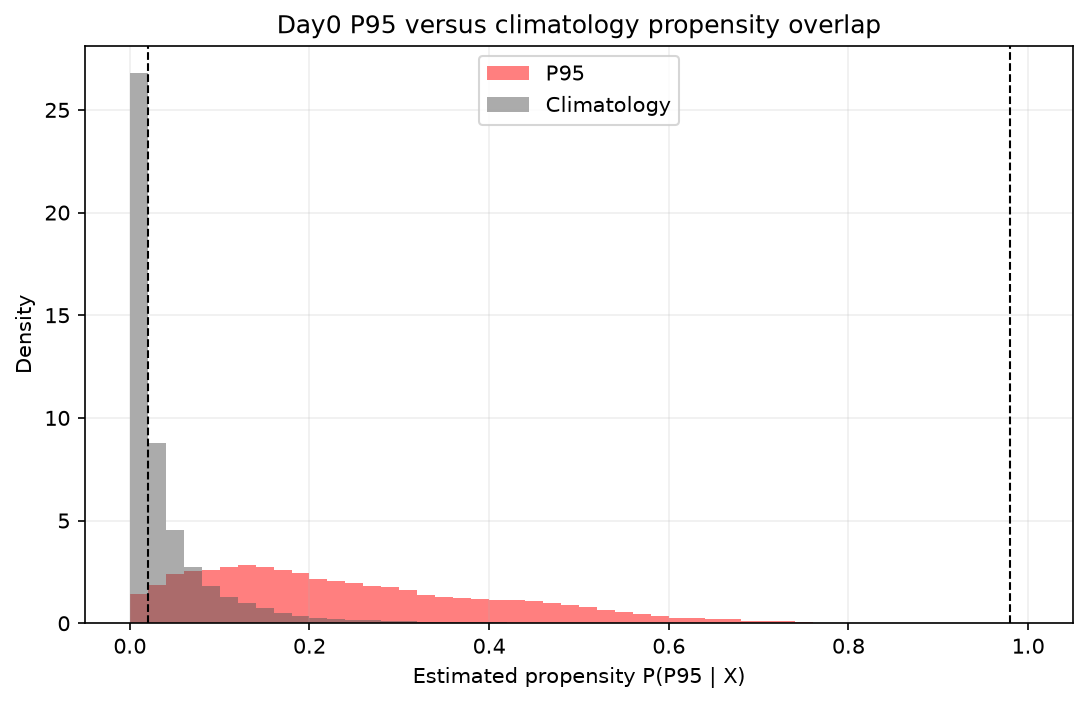

,bounds,retained_total,retained_P95,retained_climatology,removed_P95,removed_climatology,percentage_removed
0,0.01–0.99,2382547,185034,2197513,2440,1364473,36.456263
1,0.02–0.98,1835935,182179,1653756,5295,1908230,51.034682
2,0.05–0.95,1013200,171049,842151,16425,2719835,72.977442


In [10]:
X_all = causal_df[control_features].to_numpy(dtype='float32')
W_all = causal_df['treatment'].to_numpy(dtype='int8')
propensity_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=CF_SEED)
propensity_model = HistGradientBoostingClassifier(max_iter=120, learning_rate=.06,
                                                   max_leaf_nodes=31, random_state=CF_SEED)
propensity_hat = cross_val_predict(propensity_model, X_all, W_all, cv=propensity_cv,
                                   method='predict_proba', n_jobs=3)[:, 1]
causal_df['propensity'] = propensity_hat

def propensity_summary(values, label):
    q = np.percentile(values, [0, 1, 5, 25, 50, 75, 95, 99, 100])
    return {'group': label, **dict(zip(['min', 'P01', 'P05', 'P25', 'median', 'P75', 'P95', 'P99', 'max'], q))}

propensity_diagnostics = pd.DataFrame([
    propensity_summary(propensity_hat[W_all == 1], 'P95'),
    propensity_summary(propensity_hat[W_all == 0], 'Climatology'),
    propensity_summary(propensity_hat, 'All'),
])
display(propensity_diagnostics)

fig, ax = plt.subplots(figsize=(8.5, 5), dpi=150)
bins = np.linspace(0, 1, 51)
ax.hist(propensity_hat[W_all == 1], bins=bins, density=True, alpha=.5, color='red', label='P95')
ax.hist(propensity_hat[W_all == 0], bins=bins, density=True, alpha=.5, color='0.35', label='Climatology')
ax.axvline(.02, color='black', linestyle='--', linewidth=1)
ax.axvline(.98, color='black', linestyle='--', linewidth=1)
ax.set(xlabel='Estimated propensity P(P95 | X)', ylabel='Density', title='Day0 P95 versus climatology propensity overlap')
ax.legend(); ax.grid(alpha=.2); plt.show(); plt.close(fig)

trim_threshold_rows = []
for lower, upper in [(.01, .99), (.02, .98), (.05, .95)]:
    retained = (propensity_hat >= lower) & (propensity_hat <= upper)
    trim_threshold_rows.append({
        'bounds': f'{lower:.02f}–{upper:.02f}',
        'retained_total': int(retained.sum()),
        'retained_P95': int(W_all[retained].sum()),
        'retained_climatology': int((W_all[retained] == 0).sum()),
        'removed_P95': int(W_all.sum() - W_all[retained].sum()),
        'removed_climatology': int((W_all == 0).sum() - (W_all[retained] == 0).sum()),
        'percentage_removed': 100 * float((~retained).mean()),
    })
trim_threshold_report = pd.DataFrame(trim_threshold_rows)
display(trim_threshold_report)
trim_main = (propensity_hat >= PROPENSITY_BOUNDS[0]) & (propensity_hat <= PROPENSITY_BOUNDS[1])


### Four causal-forest outcomes

Every forest below is newly trained for P95 treatment versus the non-P95 climatological/background control. The all-day precipitation model is the primary outcome and retains dry days. Wet-day occurrence uses all eligible samples and is measured as a probability difference. Heavy occurrence uses the gridwise P95 threshold calculated from **all JJA Day0 precipitation**, not from dust-selected samples.

#### Conditional Wet-Day Intensity Analysis

Because wet-day status may itself be affected by dust, conditioning on wet days can introduce post-treatment selection. Therefore, this analysis is interpreted as the estimated P95-versus-climatology precipitation-intensity difference conditional on observed wet days, rather than the primary causal effect.

This analysis conditions on observed wet days and is therefore interpreted more cautiously than the all-day precipitation and wet-day occurrence analyses.

In [11]:
def cluster_year_effect_summary(tau, weights, years):
    point = float(np.average(tau, weights=weights))
    year_effects = []
    for year in np.unique(years):
        use = years == year
        year_effects.append(np.average(tau[use], weights=weights[use]))
    year_effects = np.asarray(year_effects)
    se = float(year_effects.std(ddof=1) / np.sqrt(year_effects.size))
    crit = float(scipy_stats.t.ppf(.975, year_effects.size - 1))
    pvalue = float(2 * scipy_stats.t.sf(abs(point / se), year_effects.size - 1)) if se > 0 else np.nan
    return {'ATE': point, 'SE': se, 'CI_low': point-crit*se, 'CI_high': point+crit*se,
            'p_value': pvalue, 'year_clusters': int(year_effects.size)}

def calibration_analogue(Y, W, tau, propensity, X, binary_outcome=False):
    cv = StratifiedKFold(3, shuffle=True, random_state=CF_SEED) if binary_outcome else KFold(3, shuffle=True, random_state=CF_SEED)
    if binary_outcome:
        nuisance = HistGradientBoostingClassifier(max_iter=100, learning_rate=.06, random_state=CF_SEED)
        yhat = cross_val_predict(nuisance, X, Y.astype(int), cv=cv, method='predict_proba', n_jobs=3)[:, 1]
    else:
        nuisance = HistGradientBoostingRegressor(max_iter=100, learning_rate=.06, random_state=CF_SEED)
        yhat = cross_val_predict(nuisance, X, Y, cv=cv, method='predict', n_jobs=3)
    yres, wres = Y-yhat, W-propensity
    mean_tau = float(np.mean(tau))
    design = np.column_stack([wres*mean_tau, wres*(tau-mean_tau)])
    fit = sm.OLS(yres, design).fit(cov_type='HC3')
    return pd.DataFrame({
        'term': ['mean.forest.prediction', 'differential.forest.prediction'],
        'estimate': fit.params, 'std.error': fit.bse, 't.value': fit.tvalues, 'p.value': fit.pvalues,
    })

def fit_causal_outcome(name, outcome, use_mask, propensity, binary_outcome=False):
    idx = np.where(use_mask)[0]
    X = X_all[idx]
    W = W_all[idx]
    Y = causal_df[outcome].to_numpy(dtype=float)[idx]
    e = propensity[idx]
    overlap_weight = e * (1-e)
    model_y = (HistGradientBoostingClassifier(max_iter=100, learning_rate=.06, random_state=CF_SEED)
               if binary_outcome else
               HistGradientBoostingRegressor(max_iter=100, learning_rate=.06, random_state=CF_SEED))
    model = CausalForestDML(
        model_y=model_y,
        model_t=HistGradientBoostingClassifier(max_iter=100, learning_rate=.06, random_state=CF_SEED),
        discrete_outcome=binary_outcome, discrete_treatment=True, cv=3,
        n_estimators=CF_TREES, min_samples_leaf=50, max_samples=.10,
        honest=True, inference=True, subforest_size=4, n_jobs=-1, random_state=CF_SEED,
    )
    print(f'Fitting {name}: n={len(idx):,}, P95={W.sum():,}, Climatology={(W==0).sum():,}, trees={CF_TREES}')
    model.fit(Y, W, X=X, sample_weight=overlap_weight)
    tau = np.asarray(model.effect(X)).ravel()
    ate_overlap = cluster_year_effect_summary(tau, overlap_weight, causal_df.year.to_numpy()[idx])
    ate_all = cluster_year_effect_summary(tau, np.ones_like(overlap_weight), causal_df.year.to_numpy()[idx])
    calibration = calibration_analogue(Y, W, tau, e, X, binary_outcome=binary_outcome)
    cate = dict(zip(['mean', 'std', 'P05', 'P25', 'median', 'P75', 'P95'],
                    [tau.mean(), tau.std(ddof=1), *np.percentile(tau, [5, 25, 50, 75, 95])]))
    return {'name': name, 'outcome': outcome, 'idx': idx, 'tau': tau, 'model': model,
            'ate_overlap': ate_overlap, 'ate_all': ate_all, 'calibration': calibration,
            'cate': cate, 'importance': np.asarray(model.feature_importances_), 'propensity': e}

analysis_results = {}
analysis_results['All-day precipitation'] = fit_causal_outcome(
    'All-day precipitation', 'precip', trim_main, propensity_hat, binary_outcome=False)
analysis_results['Wet-day occurrence'] = fit_causal_outcome(
    'Wet-day occurrence', 'wet', trim_main, propensity_hat, binary_outcome=True)
analysis_results['Heavy-precip occurrence'] = fit_causal_outcome(
    'Heavy-precip occurrence', 'heavy', trim_main, propensity_hat, binary_outcome=True)

# Re-estimate overlap among observed wet days for the conditional secondary analysis.
wet_subset = causal_df.wet.to_numpy(dtype=bool)
wet_propensity = cross_val_predict(propensity_model, X_all[wet_subset], W_all[wet_subset],
                                   cv=propensity_cv, method='predict_proba', n_jobs=3)[:, 1]
wet_trim_local = ((wet_propensity >= PROPENSITY_BOUNDS[0]) & (wet_propensity <= PROPENSITY_BOUNDS[1]))
wet_use_global = np.zeros(len(causal_df), dtype=bool)
wet_use_global[np.where(wet_subset)[0][wet_trim_local]] = True
wet_propensity_global = np.full(len(causal_df), np.nan)
wet_propensity_global[wet_subset] = wet_propensity
print('Conditional wet-day propensity overlap:')
display(pd.DataFrame([
    propensity_summary(wet_propensity[W_all[wet_subset] == 1], 'P95 wet'),
    propensity_summary(wet_propensity[W_all[wet_subset] == 0], 'Climatology wet'),
    propensity_summary(wet_propensity, 'All wet'),
]))
analysis_results['Wet-day intensity'] = fit_causal_outcome(
    'Conditional wet-day intensity', 'precip', wet_use_global, wet_propensity_global, binary_outcome=False)

for name, result in analysis_results.items():
    print('\n', name)
    print('Overlap-weighted ATE:', result['ate_overlap'])
    print('All-sample ATE sensitivity:', result['ate_all'])
    print('CATE distribution:', result['cate'])
    print('Calibration analogue:')
    display(result['calibration'])

Fitting All-day precipitation: n=1,835,935, P95=182,179, Climatology=1,653,756, trees=2000


Fitting Wet-day occurrence: n=1,835,935, P95=182,179, Climatology=1,653,756, trees=2000


Fitting Heavy-precip occurrence: n=1,835,935, P95=182,179, Climatology=1,653,756, trees=2000


Conditional wet-day propensity overlap:


,group,min,P01,P05,P25,median,P75,P95,P99,max
0,P95 wet,0.001908,0.009999,0.034149,0.124708,0.262159,0.419758,0.598382,0.704347,0.974622
1,Climatology wet,0.000953,0.002104,0.003113,0.006873,0.020077,0.047596,0.153757,0.340634,0.931540
2,All wet,0.000953,0.002126,0.003167,0.007365,0.021901,0.055706,0.248002,0.491838,0.974622


...

,term,estimate,std.error,t.value,p.value
0,mean.forest.prediction,3.563859,0.869604,4.098254,0.000042
1,differential.forest.prediction,5.480433,0.030334,180.667813,0.000000



 Heavy-precip occurrence
Overlap-weighted ATE: {'ATE': 0.0042778811737463, 'SE': 0.0004435771253269308, 'CI_low': 0.003326502860280252, 'CI_high': 0.005229259487212349, 'p_value': 1.4606951259046197e-07, 'year_clusters': 15}
All-sample ATE sensitivity: {'ATE': 0.004482892430383818, 'SE': 0.00029080846922357865, 'CI_low': 0.0038591702968593317, 'CI_high': 0.0051066145639083035, 'p_value': 3.544232950902761e-10, 'year_clusters': 15}
CATE distribution: {'mean': np.float64(0.004482892430383818), 'std': np.float64(0.014628079364701665), 'P05': np.float64(-0.009447797496664188), 'P25': np.float64(-0.0014215638530605795), 'median': np.float64(0.00043139503430133537), 'P75': np.float64(0.006698264465336219), 'P95': np.float64(0.03227474825187516)}
Calibration analogue:


,term,estimate,std.error,t.value,p.value
0,mean.forest.prediction,1.150838,0.119668,9.616936,6.782117e-22
1,differential.forest.prediction,5.352728,0.069221,77.328496,0.000000e+00



 Wet-day intensity
Overlap-weighted ATE: {'ATE': 0.09768105541529541, 'SE': 0.028721451194891924, 'CI_low': 0.03607966923481031, 'CI_high': 0.1592824415957805, 'p_value': 0.004304499239733399, 'year_clusters': 15}
All-sample ATE sensitivity: {'ATE': 0.10911757244298212, 'SE': 0.0190885685314959, 'CI_low': 0.06817666476522301, 'CI_high': 0.15005848012074124, 'p_value': 5.329851852647291e-05, 'year_clusters': 15}
CATE distribution: {'mean': np.float64(0.10911757244298212), 'std': np.float64(0.4656592691709686), 'P05': np.float64(-0.6665224187152554), 'P25': np.float64(-0.12081441012521342), 'median': np.float64(0.10751818795989342), 'P75': np.float64(0.3561142160348132), 'P95': np.float64(0.8605248615594392)}
Calibration analogue:


,term,estimate,std.error,t.value,p.value
0,mean.forest.prediction,0.916465,0.204645,4.478321,0.000008
1,differential.forest.prediction,5.693979,0.069789,81.589015,0.000000


,ATE,SE,CI_low,CI_high,p_value,year_clusters,bounds,n,P95,Climatology,method
0,0.009679,0.014125,-0.020617,0.039974,0.504397,15,0.01–0.99,2382547,185034,2197513,fixed 0.02–0.98 forest; target-population sens...
1,0.008356,0.014769,-0.023319,0.040032,0.580471,15,0.02–0.98,1835935,182179,1653756,fixed 0.02–0.98 forest; target-population sens...
2,0.008102,0.019311,-0.033316,0.049519,0.681189,15,0.05–0.95,1013200,171049,842151,fixed 0.02–0.98 forest; target-population sens...


Sensitivity rows change the target population; the forest remains the preregistered 0.02–0.98 main model.


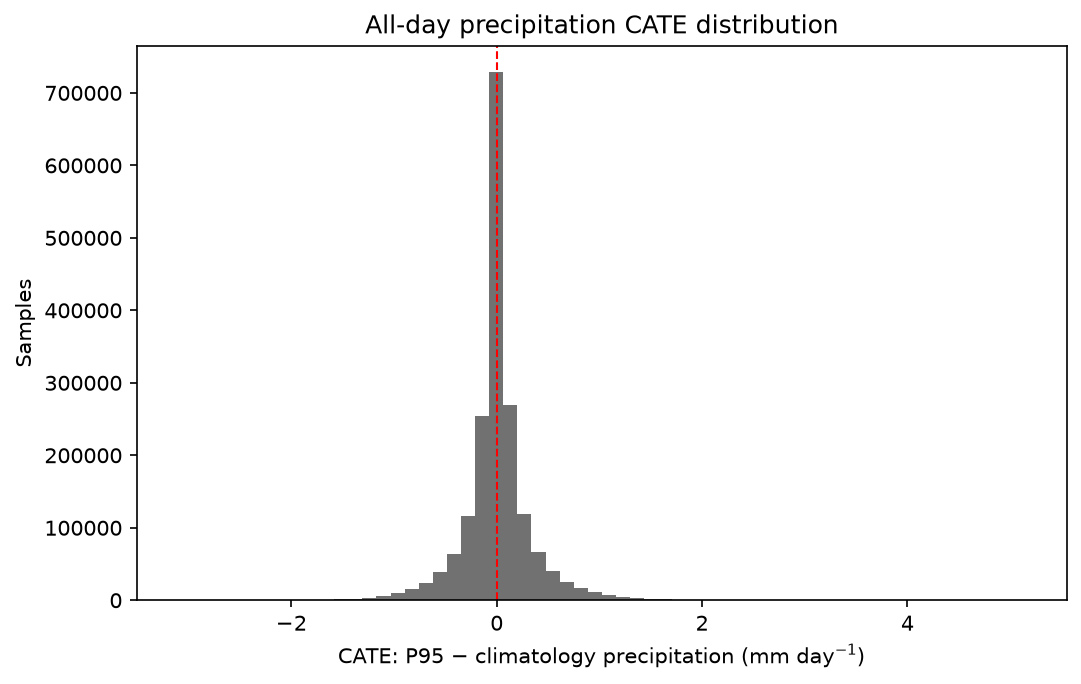

,CATE tercile,feature,mean,median,P25,P75,IQR
0,Bottom tercile,CAPE,473.149475,232.140625,40.572918,655.354553,614.781635
1,Bottom tercile,omega500,-0.038930,-0.008221,-0.089687,0.040668,0.130355
2,Bottom tercile,omega700,-0.037850,-0.013832,-0.102180,0.046383,0.148563
3,Bottom tercile,RH700,55.042542,55.546162,42.663988,67.895142,25.231153
4,Bottom tercile,TCWV,31.970711,32.160320,24.824528,39.412846,14.588318
5,Bottom tercile,Z500,5839.464355,5858.540527,5795.974365,5898.929688,102.955322
6,Middle tercile,CAPE,168.173264,1.688378,0.000000,88.899029,88.899029
7,Middle tercile,omega500,0.016711,0.029081,-0.028778,0.076842,0.105621
8,Middle tercile,omega700,0.001156,0.024896,-0.078145,0.098192,0.176336
9,Middle tercile,RH700,34.983620,31.353884,20.147609,47.469243,27.321634


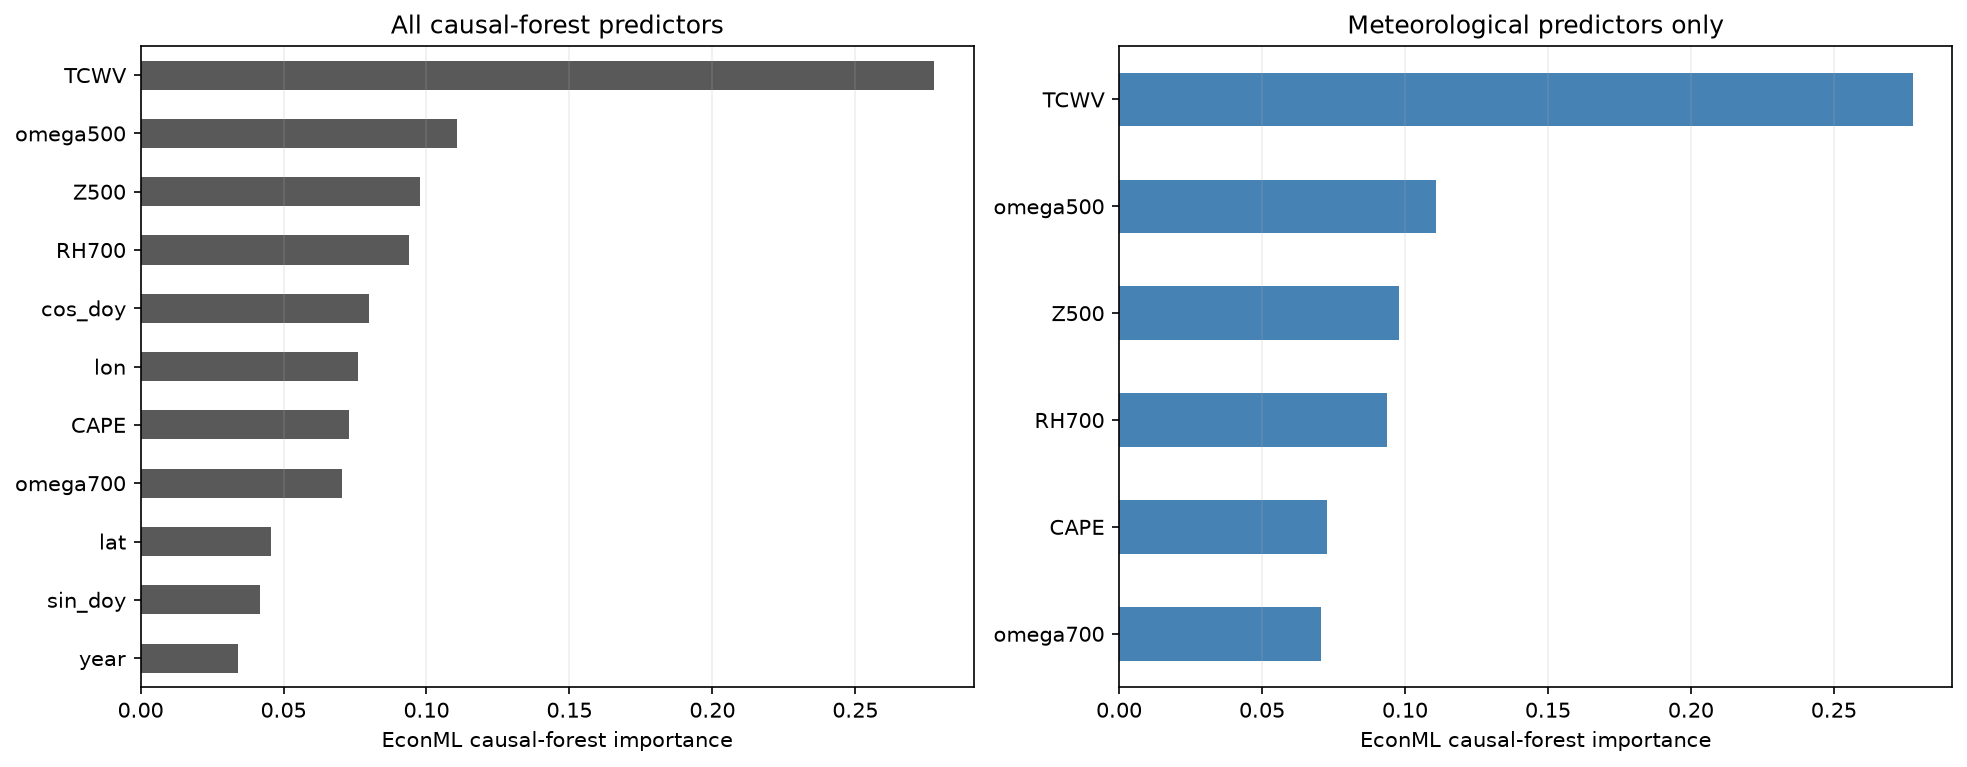

,importance
TCWV,0.277622
omega500,0.110791
Z500,0.097851
RH700,0.093764
CAPE,0.072814
omega700,0.070452


In [12]:
# Main-model trimming sensitivity, CATE distribution, atmospheric terciles, and importance.
main = analysis_results['All-day precipitation']
# Fixed-main-forest target-population sensitivity: predict CATE for every complete case,
# then change only the explicitly reported propensity target population.
main_tau_complete = np.asarray(main['model'].effect(X_all)).ravel()
sensitivity_rows = []
for lower, upper in [(.01, .99), (.02, .98), (.05, .95)]:
    use_global = (propensity_hat >= lower) & (propensity_hat <= upper)
    idx = np.where(use_global)[0]
    tau = main_tau_complete[idx]
    e = propensity_hat[idx]
    row = cluster_year_effect_summary(tau, e*(1-e), causal_df.year.to_numpy()[idx])
    row.update({'bounds': f'{lower:.02f}–{upper:.02f}', 'n': len(idx),
                'P95': int(causal_df.treatment.to_numpy()[idx].sum()),
                'Climatology': int((causal_df.treatment.to_numpy()[idx] == 0).sum()),
                'method': 'fixed 0.02–0.98 forest; target-population sensitivity'})
    sensitivity_rows.append(row)
sensitivity_table = pd.DataFrame(sensitivity_rows)
display(sensitivity_table)
print('Sensitivity rows change the target population; the forest remains the preregistered 0.02–0.98 main model.')

fig, ax = plt.subplots(figsize=(8, 4.8), dpi=150)
ax.hist(main['tau'], bins=60, color='0.3', alpha=.8)
ax.axvline(0, color='red', linestyle='--', linewidth=1)
ax.set(xlabel='CATE: P95 − climatology precipitation (mm day$^{-1}$)', ylabel='Samples',
       title='All-day precipitation CATE distribution')
plt.show(); plt.close(fig)

main_rows = causal_df.iloc[main['idx']].copy()
main_rows['tau_hat'] = main['tau']
main_rows['CATE tercile'] = pd.qcut(main_rows.tau_hat, 3,
                                    labels=['Bottom tercile', 'Middle tercile', 'Top tercile'])
tercile_rows = []
for tercile, group in main_rows.groupby('CATE tercile', observed=True):
    for feature in met_features:
        q25, median, q75 = np.percentile(group[feature], [25, 50, 75])
        tercile_rows.append({'CATE tercile': tercile, 'feature': feature,
                             'mean': group[feature].mean(), 'median': median,
                             'P25': q25, 'P75': q75, 'IQR': q75-q25})
cate_tercile_atmosphere = pd.DataFrame(tercile_rows)
display(cate_tercile_atmosphere)

importance_all = pd.Series(main['importance'], index=control_features).sort_values(ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=150, constrained_layout=True)
importance_all.plot.barh(ax=axes[0], color='0.35', title='All causal-forest predictors')
importance_all.loc[met_features].sort_values().plot.barh(ax=axes[1], color='steelblue',
                                                         title='Meteorological predictors only')
for ax in axes: ax.set_xlabel('EconML causal-forest importance'); ax.grid(axis='x', alpha=.2)
plt.show(); plt.close(fig)
top_met_variables = importance_all.loc[met_features].sort_values(ascending=False)
display(top_met_variables.rename('importance').to_frame())

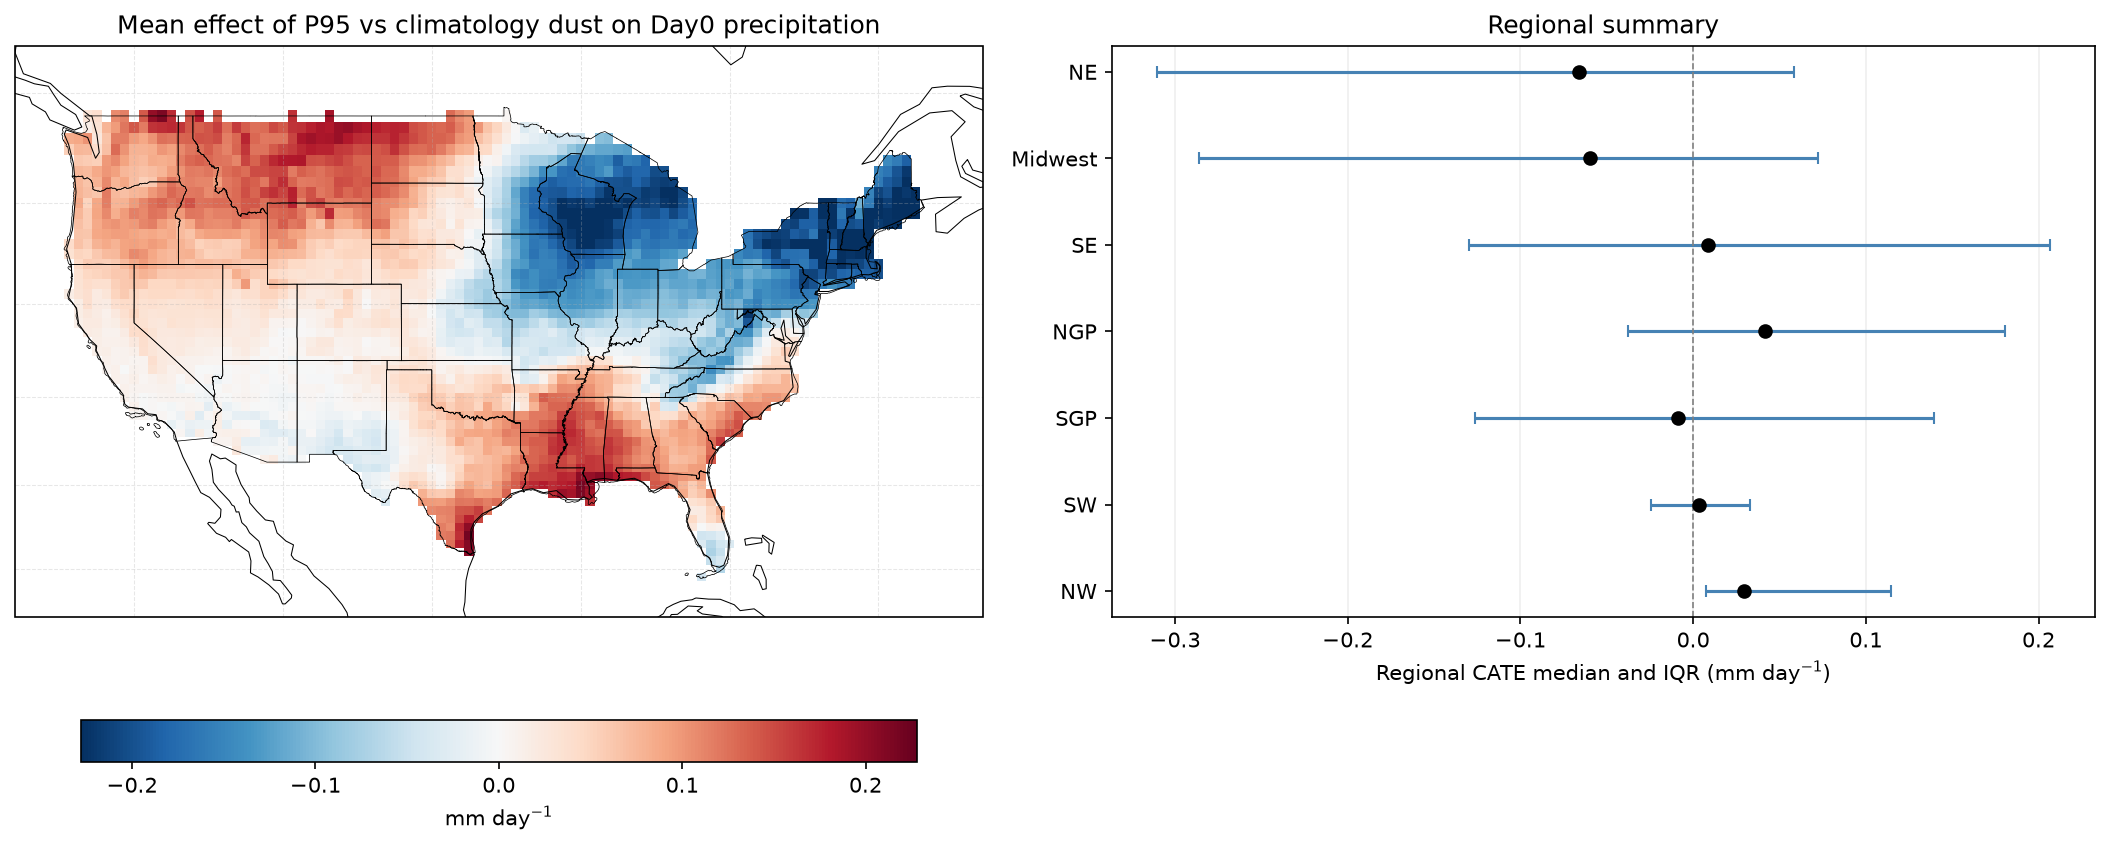

All-day precipitation regional CATE summary


,mean,median,P25,P75,sample_size
region,,,,,
NE,-0.162964,-0.066373,-0.310703,0.058277,132593
Midwest,-0.113616,-0.059583,-0.286025,0.072232,310185
SE,0.065479,0.008364,-0.129824,0.206705,358366
NGP,0.084360,0.041533,-0.037645,0.180815,252296
SGP,0.039809,-0.008751,-0.126323,0.139640,274113
SW,0.012769,0.003242,-0.024234,0.033097,383010
NW,0.091933,0.029214,0.007498,0.114617,125372


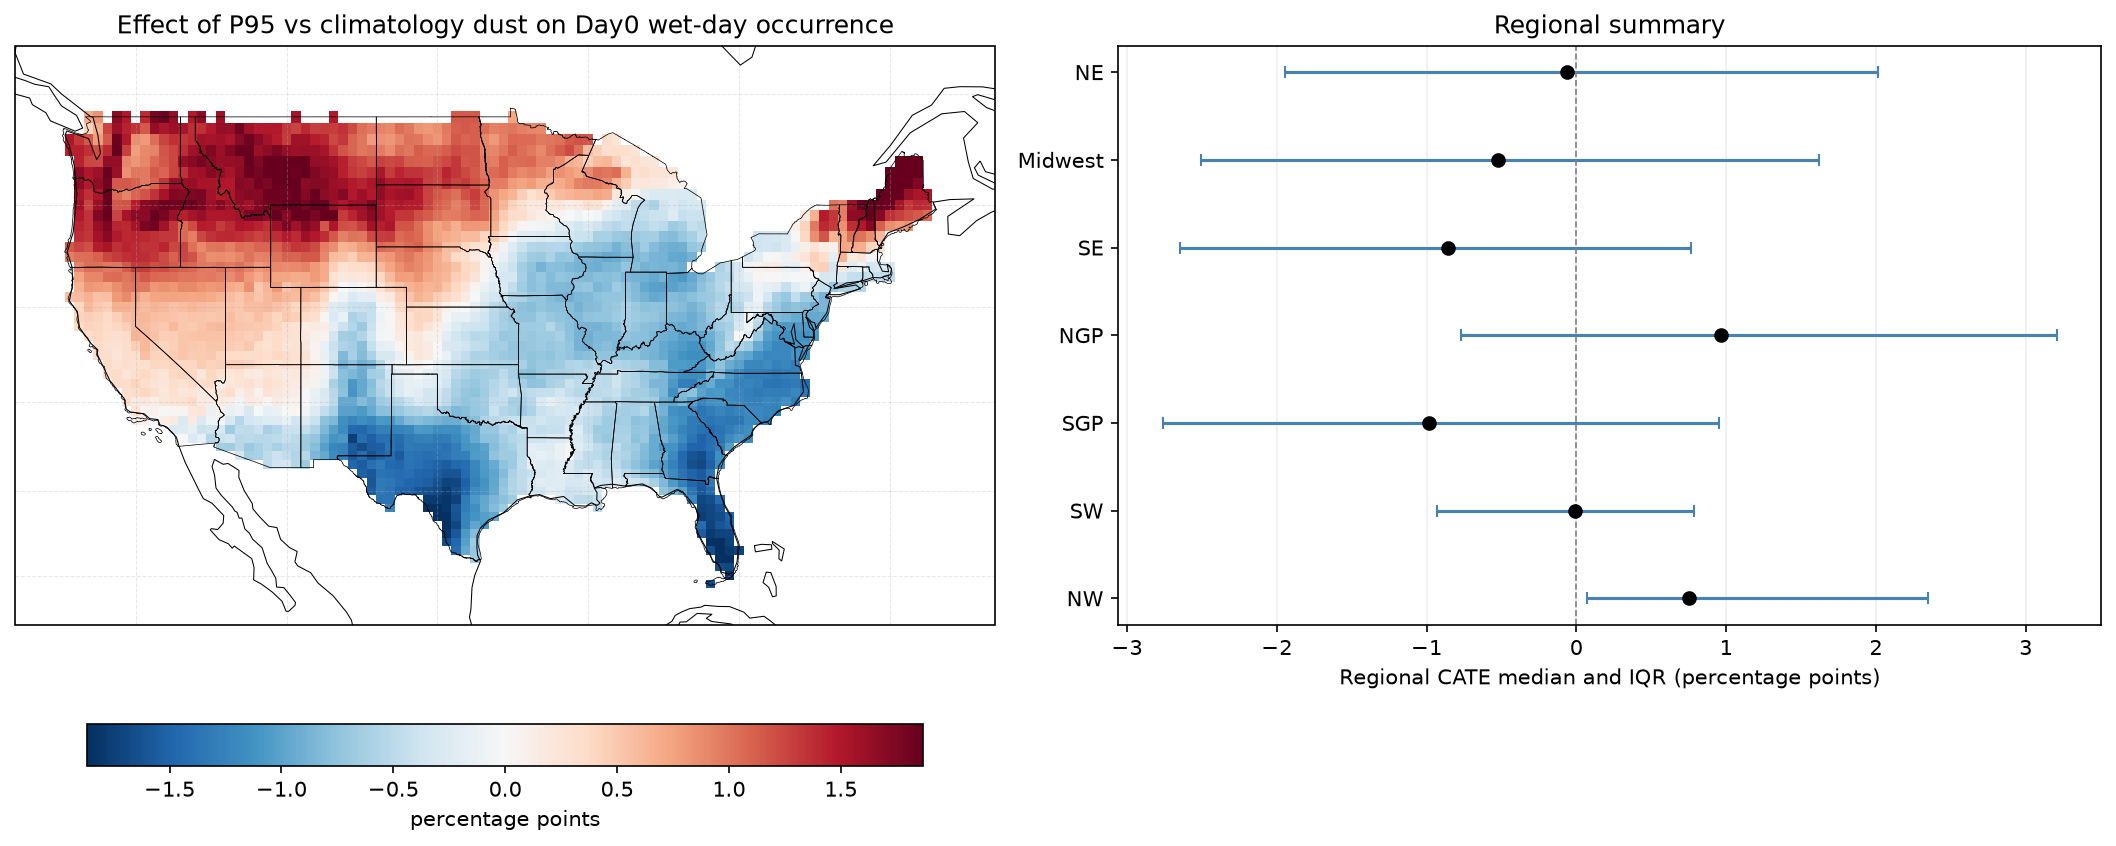

Wet-day occurrence regional CATE summary


,mean,median,P25,P75,sample_size
region,,,,,
NE,0.076228,-0.062720,-1.942899,2.017281,132593
Midwest,-0.358370,-0.525980,-2.507953,1.620288,310185
SE,-0.905730,-0.857117,-2.643755,0.768604,358366
NGP,1.130486,0.963215,-0.769965,3.206290,252296
SGP,-0.817025,-0.985436,-2.759665,0.951332,274113
SW,0.017590,-0.011073,-0.932537,0.782982,383010
NW,1.347229,0.752958,0.069795,2.347524,125372


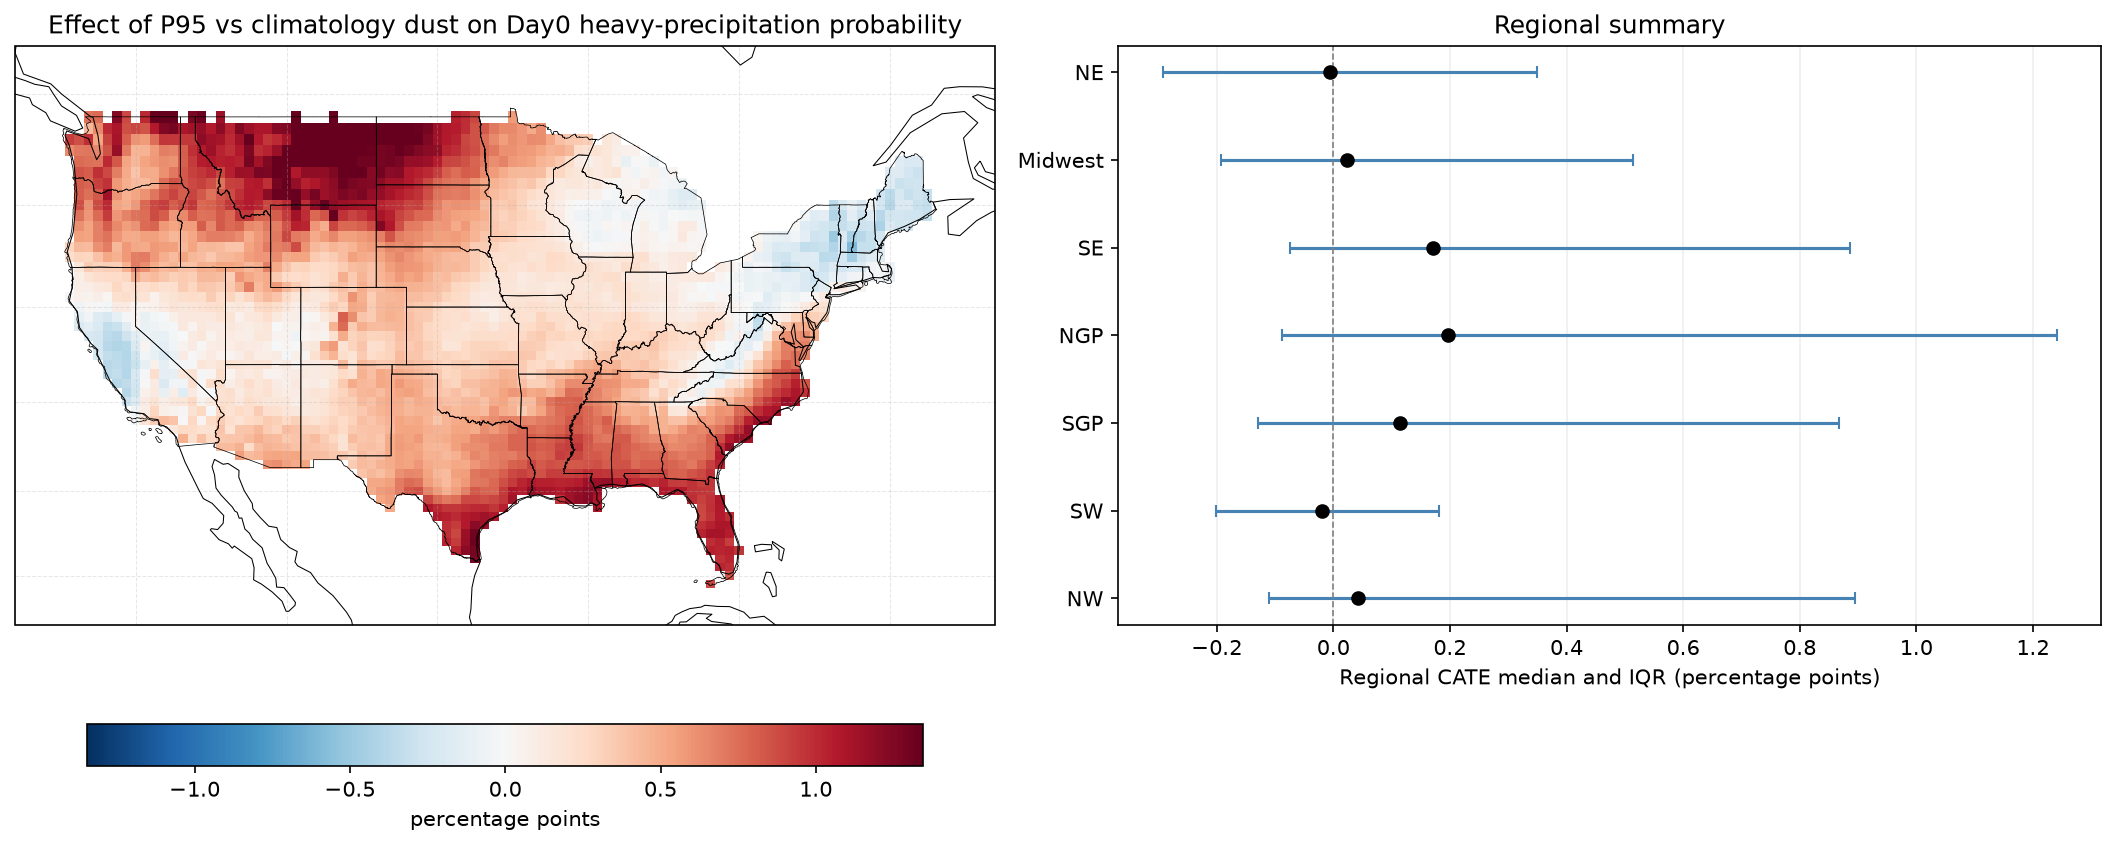

Heavy-precip occurrence regional CATE summary


,mean,median,P25,P75,sample_size
region,,,,,
NE,-0.084645,-0.005778,-0.292238,0.349694,132593
Midwest,0.196076,0.023908,-0.192716,0.514688,310185
SE,0.673921,0.170429,-0.074767,0.886540,358366
NGP,0.845569,0.197489,-0.088380,1.240468,252296
SGP,0.551950,0.115104,-0.129561,0.867029,274113
SW,0.211960,-0.018809,-0.200651,0.181418,383010
NW,0.686836,0.042306,-0.110540,0.894220,125372


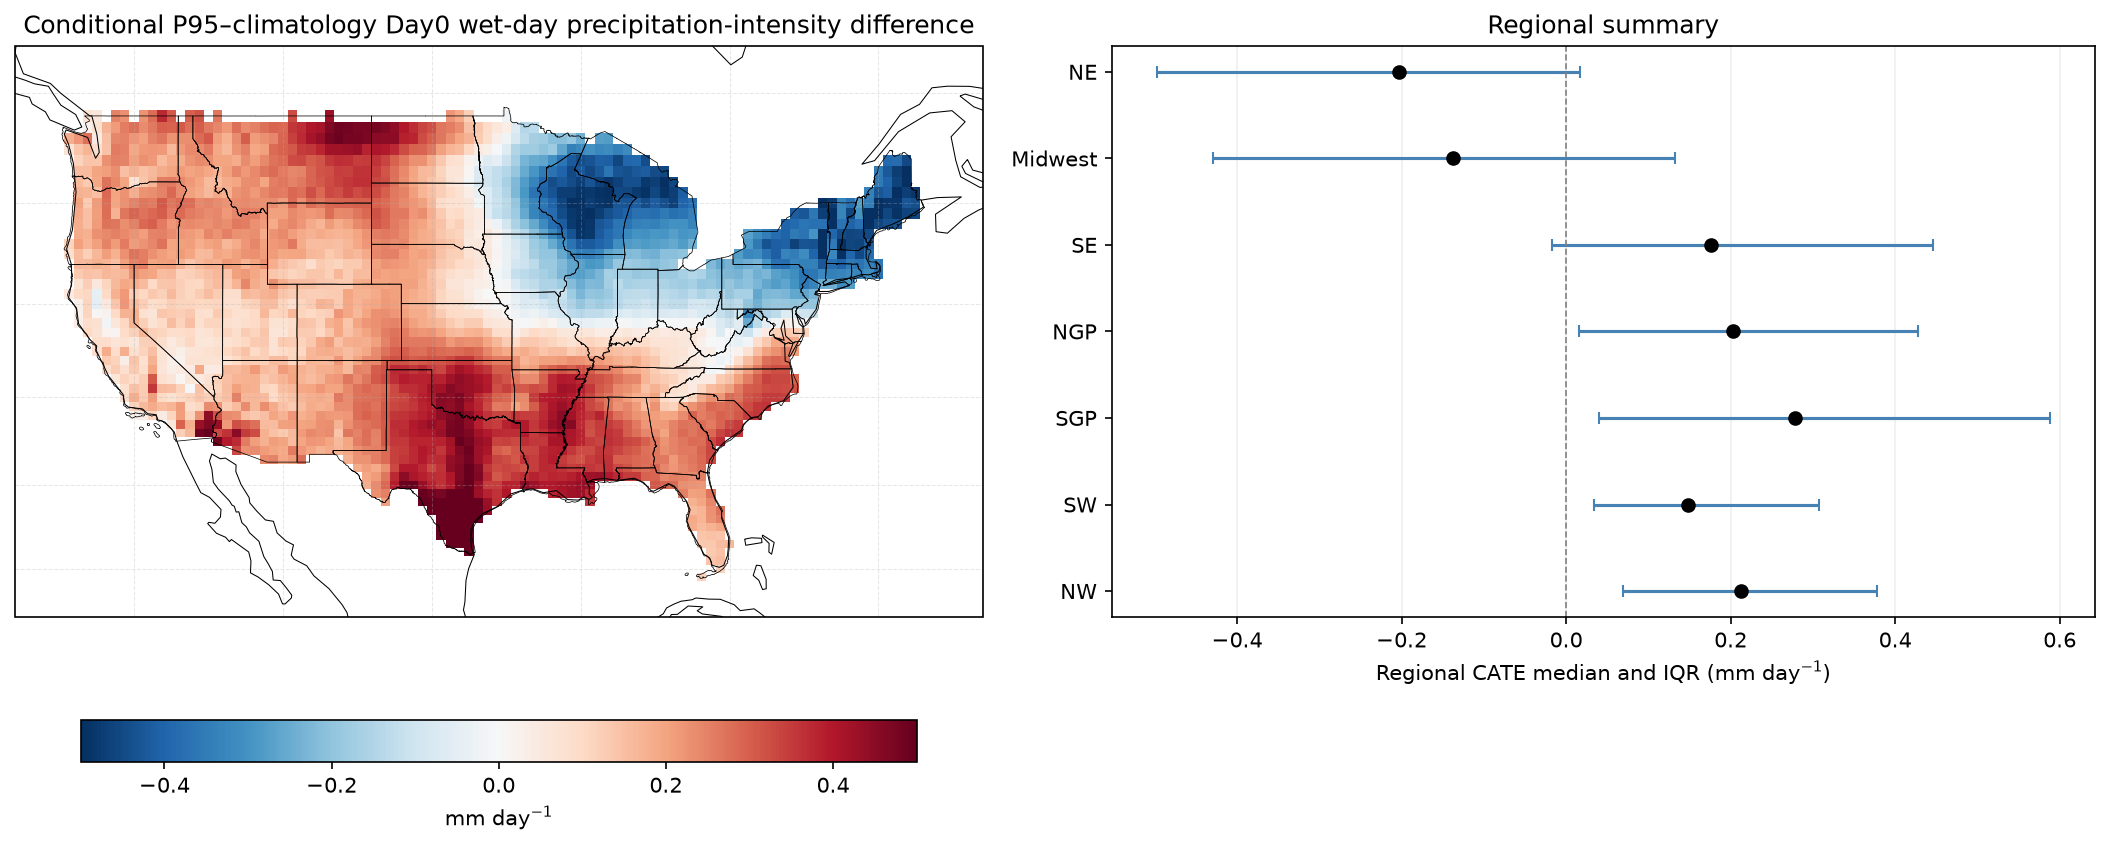

Wet-day intensity regional CATE summary


,mean,median,P25,P75,sample_size
region,,,,,
NE,-0.279482,-0.203470,-0.497941,0.016525,70921
Midwest,-0.162841,-0.137122,-0.428854,0.131833,152356
SE,0.250315,0.176412,-0.016947,0.445613,186451
NGP,0.210484,0.203188,0.015011,0.427532,104558
SGP,0.343748,0.278326,0.039738,0.588316,99249
SW,0.189985,0.148017,0.034173,0.307153,69910
NW,0.216380,0.212822,0.068547,0.378448,29171


Wet/heavy probability effects are plotted in percentage points; stored tau remains probability difference.


In [13]:
# Spatial CATE maps and regional summaries for all four outcomes.
def result_spatial_summary(result, probability=False):
    frame = causal_df.iloc[result['idx']][['lat', 'lon', 'region']].copy()
    scale = 100.0 if probability else 1.0
    frame['tau_plot'] = result['tau'] * scale
    grid = frame.groupby(['lat', 'lon']).tau_plot.mean().unstack('lon').reindex(index=lat, columns=lon)
    regional = frame.groupby('region', observed=True).tau_plot.agg(
        mean='mean', median='median', P25=lambda x: x.quantile(.25),
        P75=lambda x: x.quantile(.75), sample_size='size').reindex(REGION_ORDER)
    return frame, grid, regional

map_specs = {
    'All-day precipitation': ('Mean effect of P95 vs climatology dust on Day0 precipitation', 'mm day$^{-1}$', False),
    'Wet-day occurrence': ('Effect of P95 vs climatology dust on Day0 wet-day occurrence', 'percentage points', True),
    'Heavy-precip occurrence': ('Effect of P95 vs climatology dust on Day0 heavy-precipitation probability', 'percentage points', True),
    'Wet-day intensity': ('Conditional P95–climatology Day0 wet-day precipitation-intensity difference', 'mm day$^{-1}$', False),
}
regional_cate_tables = {}
for name, (title, units, probability) in map_specs.items():
    frame, grid, regional = result_spatial_summary(analysis_results[name], probability)
    regional_cate_tables[name] = regional
    vmax = max(float(np.nanpercentile(np.abs(grid.values), 98)), 1e-6)
    fig = plt.figure(figsize=(14, 5.5), dpi=150, constrained_layout=True)
    ax_map = fig.add_subplot(1, 2, 1, projection=ccrs.Mercator())
    ax_reg = fig.add_subplot(1, 2, 2)
    im = ax_map.pcolormesh(lon, lat, np.ma.masked_invalid(grid.values), transform=ccrs.PlateCarree(),
                           cmap='RdBu_r', vmin=-vmax, vmax=vmax, shading='auto')
    setup_map_ax(ax_map); ax_map.set_title(title)
    fig.colorbar(im, ax=ax_map, orientation='horizontal', pad=.05, label=units, shrink=.85)
    ypos = np.arange(len(REGION_ORDER))
    ax_reg.errorbar(regional['median'], ypos,
                    xerr=[regional['median']-regional['P25'], regional['P75']-regional['median']],
                    fmt='o', color='black', ecolor='steelblue', capsize=3)
    ax_reg.axvline(0, color='gray', linestyle='--', linewidth=.8)
    ax_reg.set_yticks(ypos, REGION_ORDER); ax_reg.invert_yaxis()
    ax_reg.set(xlabel=f'Regional CATE median and IQR ({units})', title='Regional summary')
    ax_reg.grid(axis='x', alpha=.2)
    plt.show(); plt.close(fig)
    print(name, 'regional CATE summary')
    display(regional)

print('Wet/heavy probability effects are plotted in percentage points; stored tau remains probability difference.')

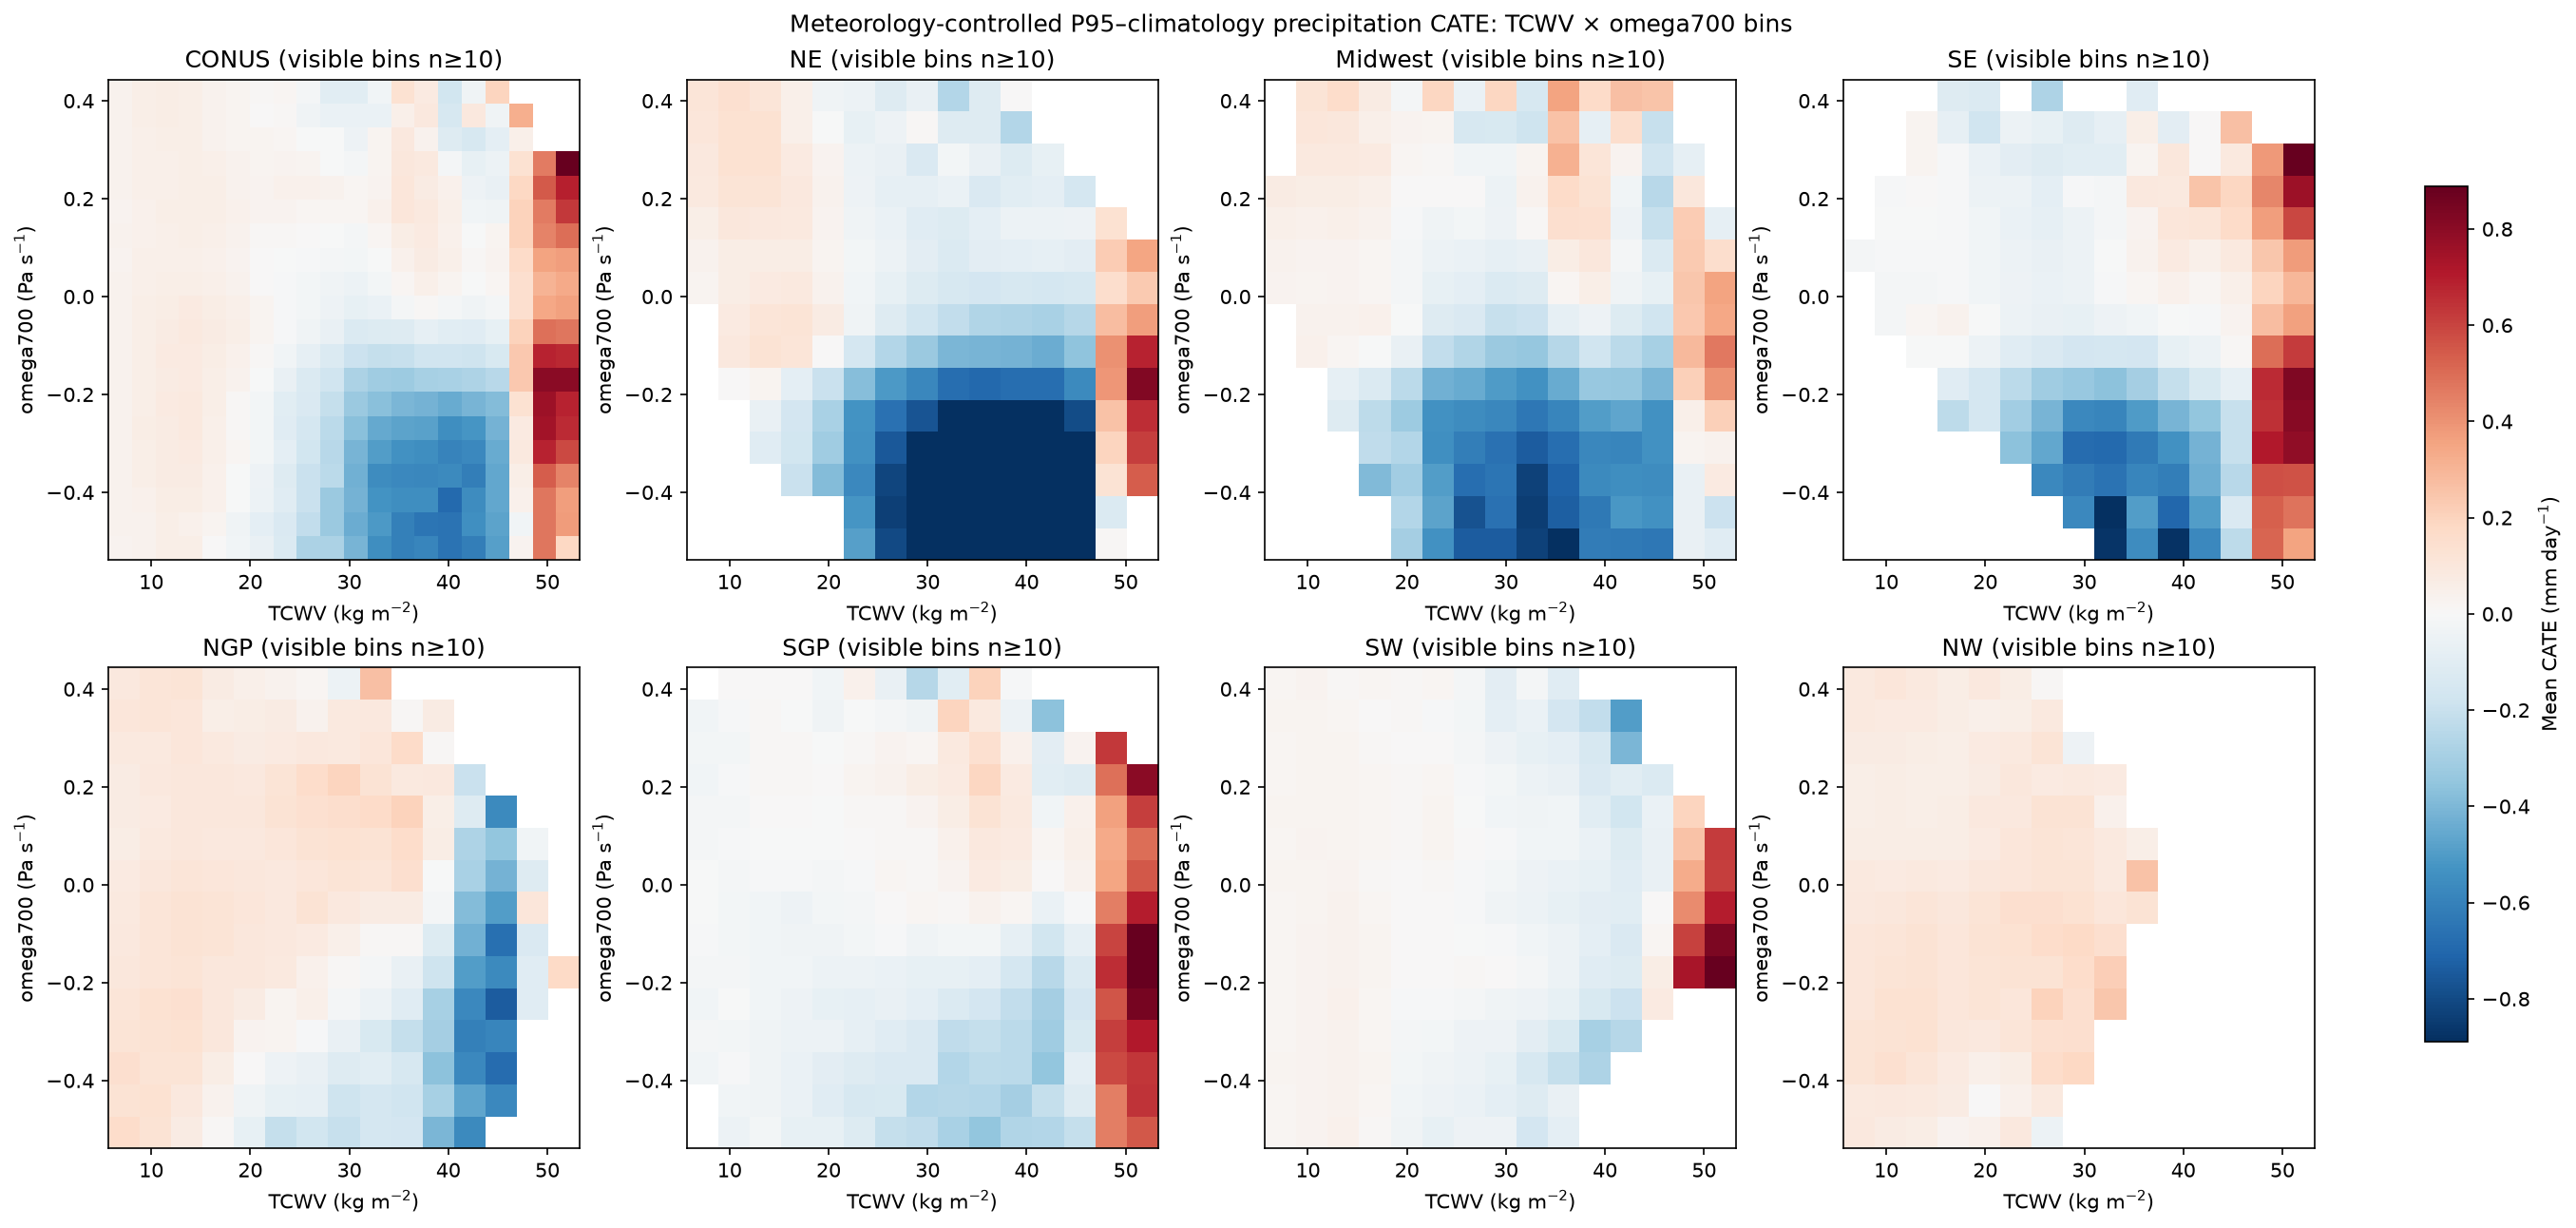

CATE binning uses the same CONUS 20×20 and regional 15×15 physical-value edges as the existing diagnostics.


In [14]:
# Meteorology-controlled main CATE in the existing TCWV × omega700 physical-value bins.
def binned_cate(frame, domain):
    xedges, yedges = domain_edges(domain)
    mask = np.ones(len(frame), dtype=bool) if domain == 'CONUS' else frame.region.eq(domain).to_numpy()
    x = frame.loc[mask, 'TCWV'].to_numpy()
    y = frame.loc[mask, 'omega700'].to_numpy()
    tau = frame.loc[mask, 'tau_hat'].to_numpy()
    count, _, _ = np.histogram2d(y, x, bins=[yedges, xedges])
    total, _, _ = np.histogram2d(y, x, bins=[yedges, xedges], weights=tau)
    mean_tau = np.full_like(total, np.nan, dtype=float)
    np.divide(total, count, out=mean_tau, where=count >= MIN_SAMPLES)
    return mean_tau, count, xedges, yedges

cate_binning = {domain: binned_cate(main_rows, domain) for domain in BINNING_DOMAINS}
all_visible = np.concatenate([v[0][np.isfinite(v[0])] for v in cate_binning.values()])
cate_bin_vmax = max(float(np.nanpercentile(np.abs(all_visible), 98)), 1e-6)
fig, axes = plt.subplots(2, 4, figsize=(18, 8.5), dpi=150, constrained_layout=True)
for ax, domain in zip(axes.ravel(), BINNING_DOMAINS):
    mean_tau, count, xedges, yedges = cate_binning[domain]
    im = ax.pcolormesh(xedges, yedges, mean_tau, cmap='RdBu_r',
                       vmin=-cate_bin_vmax, vmax=cate_bin_vmax, shading='flat')
    ax.set(title=f'{domain} (visible bins n≥{MIN_SAMPLES})', xlabel='TCWV (kg m$^{-2}$)',
           ylabel='omega700 (Pa s$^{-1}$)')
fig.colorbar(im, ax=axes, label='Mean CATE (mm day$^{-1}$)', shrink=.8)
fig.suptitle('Meteorology-controlled P95–climatology precipitation CATE: TCWV × omega700 bins')
plt.show(); plt.close(fig)
print('CATE binning uses the same CONUS 20×20 and regional 15×15 physical-value edges as the existing diagnostics.')

### Interpretation limitation

This design uses Day0 DOD, Day0 precipitation, and Day0 meteorology exactly as specified. Because Day0 meteorological variables may co-evolve with dust and precipitation, the results should be interpreted as **estimated P95-versus-climatology dust effects conditional on observed Day0 meteorological conditions**, not definitive causal proof.

In [15]:
summary_rows = []
interpretations = {
    'All-day precipitation': 'Primary causal analysis',
    'Wet-day occurrence': 'Primary/secondary causal probability analysis',
    'Heavy-precip occurrence': 'Secondary causal probability analysis',
    'Wet-day intensity': 'Conditional wet-day analysis; interpret cautiously',
}
for name, result in analysis_results.items():
    ate = result['ate_overlap']
    differential = result['calibration'].set_index('term').loc['differential.forest.prediction']
    summary_rows.append({'Outcome': name, 'ATE': ate['ATE'],
                         '95% CI': f"[{ate['CI_low']:.4g}, {ate['CI_high']:.4g}]",
                         'calibration': f"differential p={differential['p.value']:.3g}",
                         'interpretation': interpretations[name]})
causal_summary_table = pd.DataFrame(summary_rows)
display(causal_summary_table)

main_ate = analysis_results['All-day precipitation']['ate_overlap']
main_diff = analysis_results['All-day precipitation']['calibration'].set_index('term').loc['differential.forest.prediction']
heterogeneity = 'Yes' if main_diff['p.value'] < .05 else 'No'
print('='*49)
print('DAY0 DUST–PRECIPITATION CAUSAL FOREST SUMMARY')
print('='*49)
print('Period: 2000–2014 JJA')
print('Domain: contiguous CONUS land grid; seven reporting regions')
print('Treatment: Day0 gridwise DOD >= local JJA P95 (W=1)')
print('Control: non-P95 climatological/background Day0 conditions (DOD < local P95; W=0)')
print('Question: How does extreme high dust affect precipitation relative to climatological/background conditions under comparable meteorology?')
print(f'Wet-day definition: precipitation >= {WET_THRESHOLD} mm/day')
print('Heavy precipitation definition: gridwise P95 of all JJA Day0 precipitation')
print(f'\nTotal P95 samples: {int(W_all.sum()):,}')
print(f'Total climatology samples: {int((W_all==0).sum()):,}')
print(f'Complete-case samples: {len(causal_df):,}')
print(f'Samples after propensity trimming: {int(trim_main.sum()):,}')
print(f'Overlap trimming percentage: {100*(~trim_main).mean():.3f}%')
print('\nMain precipitation outcome')
print(f"ATE: {main_ate['ATE']:.6g} mm/day")
print(f"95% CI: [{main_ate['CI_low']:.6g}, {main_ate['CI_high']:.6g}]")
print(f"Calibration: differential estimate={main_diff['estimate']:.4g}, p={main_diff['p.value']:.4g}")
print('Heterogeneity detected:', heterogeneity)
for label, key, units in [
    ('Wet-day occurrence', 'Wet-day occurrence', 'probability difference'),
    ('Heavy precipitation probability', 'Heavy-precip occurrence', 'probability difference'),
    ('Conditional wet-day intensity', 'Wet-day intensity', 'mm/day')]:
    ate = analysis_results[key]['ate_overlap']
    print(f'\n{label}')
    print(f"ATE: {ate['ATE']:.6g} {units}")
    print(f"95% CI: [{ate['CI_low']:.6g}, {ate['CI_high']:.6g}]")
print('\nTop meteorological variables:')
for rank, (feature, value) in enumerate(top_met_variables.head(3).items(), 1):
    print(f'{rank}. {feature} ({value:.4f})')
print('\nRegional mean CATE (all-day precipitation, mm/day):')
for region in REGION_ORDER:
    print(f"{region}: {regional_cate_tables['All-day precipitation'].loc[region, 'mean']:.6g}")

,Outcome,ATE,95% CI,calibration,interpretation
0,All-day precipitation,0.008356,"[-0.02332, 0.04003]",differential p=0,Primary causal analysis
1,Wet-day occurrence,0.000698,"[-0.001947, 0.003342]",differential p=0,Primary/secondary causal probability analysis
2,Heavy-precip occurrence,0.004278,"[0.003327, 0.005229]",differential p=0,Secondary causal probability analysis
3,Wet-day intensity,0.097681,"[0.03608, 0.1593]",differential p=0,Conditional wet-day analysis; interpret cautio...


DAY0 DUST–PRECIPITATION CAUSAL FOREST SUMMARY
Period: 2000–2014 JJA
Domain: contiguous CONUS land grid; seven reporting regions
Treatment: Day0 gridwise DOD >= local JJA P95 (W=1)
Control: non-P95 climatological/background Day0 conditions (DOD < local P95; W=0)
Question: How does extreme high dust affect precipitation relative to climatological/background conditions under comparable meteorology?
Wet-day definition: precipitation >= 1.0 mm/day
Heavy precipitation definition: gridwise P95 of all JJA Day0 precipitation

Total P95 samples: 187,474
Total climatology samples: 3,561,986
Complete-case samples: 3,749,460
Samples after propensity trimming: 1,835,935
Overlap trimming percentage: 51.035%

Main precipitation outcome
ATE: 0.00835634 mm/day
95% CI: [-0.0233189, 0.0400316]
Calibration: differential estimate=5.668, p=0
Heterogeneity detected: Yes

Wet-day occurrence
ATE: 0.000697506 probability difference
95% CI: [-0.00194692, 0.00334193]

Heavy precipitation probability
ATE: 0.0042778